In [9]:
# ==============================================================================
# UNIFIED MULTI-MODE COMPARISON ENGINE
# ==============================================================================
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import yfinance as yf
import warnings
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from scipy.stats import spearmanr
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# Define the target folder globally for all inputs/outputs
data_folder = "Data"
if not os.path.exists(data_folder):
    os.makedirs(data_folder)

# ------------------------------------------------------------------------------
# PHASE 1: LOAD ORIGINAL DATA & 9 CORE FEATURES
# ------------------------------------------------------------------------------
print("[INFO] Loading base data and building original 9-factor feature sets...")

# Read from Data folder
csv_filename = os.path.join(data_folder, "Portfolio Asset Price Dataset.csv")

# Safely assigned to 'df' to prevent the ghost variable bug!
df = pd.read_csv(csv_filename, index_col=0, parse_dates=True)
monthly_returns = df.resample('ME').last().pct_change().dropna()
assets_list = [c for c in monthly_returns.columns if c != 'VFISX']

features_dict, targets_bin_dict, targets_cont_dict = {}, {}, {}

for asset in assets_list:
    df_features = pd.DataFrame(index=monthly_returns.index)
    
    # The Original 9 Features
    df_features['Ret_1M'] = monthly_returns[asset]
    df_features['Ret_3M'] = (1 + monthly_returns[asset]).rolling(3).apply(np.prod, raw=True) - 1
    df_features['Ret_6M'] = (1 + monthly_returns[asset]).rolling(6).apply(np.prod, raw=True) - 1
    df_features['Ret_12M'] = (1 + monthly_returns[asset]).rolling(12).apply(np.prod, raw=True) - 1
    df_features['Vol_3M'] = monthly_returns[asset].rolling(3).std()
    df_features['Vol_6M'] = monthly_returns[asset].rolling(6).std()
    df_features['Macro_SPY_3M'] = (1 + monthly_returns['SPY']).rolling(3).apply(np.prod, raw=True) - 1
    df_features['Macro_TLT_3M'] = (1 + monthly_returns['TLT']).rolling(3).apply(np.prod, raw=True) - 1
    df_features['Macro_VWEHX_3M'] = (1 + monthly_returns['VWEHX']).rolling(3).apply(np.prod, raw=True) - 1
    
    # Target Alignment: Continuous for IC, Binary for Classification Metrics
    future_3m_trend = (1 + monthly_returns[asset]).shift(-1).rolling(3).apply(np.prod, raw=True).shift(-2) - 1
    target_bin = (future_3m_trend > 0).astype(int)
    
    features_dict[asset] = df_features.dropna()
    targets_bin_dict[asset] = target_bin.loc[features_dict[asset].index]
    targets_cont_dict[asset] = future_3m_trend.loc[features_dict[asset].index]

# ------------------------------------------------------------------------------
# PHASE 2: ELITE ALTERNATIVE DATA INGESTION (SMART CACHING)
# ------------------------------------------------------------------------------
print("[INFO] Initializing Institutional Alternative Data (FRED & Yahoo)...")
macro_output_path = os.path.join(data_folder, "Macro Features Dataset.csv")

# Check if the frozen data vintage already exists in the Data folder
if os.path.exists(macro_output_path):
    print(f"[INFO] Found frozen macro data at '{macro_output_path}'. Loading cached data to prevent API drift...")
    alt_data_clean = pd.read_csv(macro_output_path, index_col=0, parse_dates=True)
else:
    print("[INFO] Cached data not found. Fetching live data from FRED & Yahoo APIs...")
    start_date, end_date = '2004-01-01', '2026-05-01'

    fred_tickers = ['SAHMREALTIME', 'T10YIE', 'GEPUCURRENT', 'DTWEXBGS', 'NFCI']
    fred_raw = web.DataReader(fred_tickers, 'fred', start_date, end_date)

    yfin_df = yf.download(['^SKEW', '^MOVE'], start=start_date, end=end_date)
    yfin_raw = yfin_df['Adj Close'] if 'Adj Close' in yfin_df else yfin_df['Close']
    yfin_raw = yfin_raw.ffill()

    market_daily = fred_raw.join(yfin_raw)
    market_monthly = market_daily.resample('ME').last().ffill()
    
    # Strictly align the alternative data to the exact index of your CSV 
    market_monthly = market_monthly.loc[market_monthly.index <= monthly_returns.index.max()]

    market_monthly['USD_Log_Ret_1M'] = np.log(market_monthly['DTWEXBGS'] / market_monthly['DTWEXBGS'].shift(1))
    alt_data_clean = market_monthly.drop(columns=['DTWEXBGS']).dropna()

    # EXPORT MACRO DATA TO FOLDER to freeze it for next time
    alt_data_clean.to_csv(macro_output_path)
    print(f"[INFO] Exported frozen Macro Data to: '{macro_output_path}'")

for asset in assets_list:
    features_dict[asset] = features_dict[asset].join(alt_data_clean).ffill().dropna()
    targets_bin_dict[asset] = targets_bin_dict[asset].loc[features_dict[asset].index]
    targets_cont_dict[asset] = targets_cont_dict[asset].loc[features_dict[asset].index]

print(f"[SUCCESS] Feature Space Upgraded. Form: {features_dict[assets_list[0]].shape[1]} Structural Features.")

# ------------------------------------------------------------------------------
# PHASE 3: MULTI-ARCHITECTURAL BACKTEST RUNNER LOOP 
# (EXPANDING WINDOW, PURGED, MULTI-THREADED)
# ------------------------------------------------------------------------------
evaluation_modes = ['GBX', 'ENSEMBLE']
horizon = 3  # Target resolution window

for mode in evaluation_modes:
    print("\n" + "="*85)
    if mode == 'GBX':
        print("METHODOLOGY ARCHITECTURE: STANDALONE GRADIENT BOOSTING CLASSIFIER (GBX)")
        print("="*85)
        model_instance = GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42)
    else:
        print("METHODOLOGY ARCHITECTURE: VOTE COMPOSITE ENSEMBLE (MULTI-THREADED)")
        print("="*85)
        # n_jobs=-1 unlocks all CPU cores for parallel tree building
        clf_log = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
        clf_rf = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=42, n_jobs=-1)
        clf_xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss', n_jobs=-1)
        model_instance = VotingClassifier(
            estimators=[('LogReg', clf_log), ('RandomForest', clf_rf), ('XGBoost', clf_xgb)], 
            voting='soft', 
            weights=[0.2, 0.4, 0.4],
            n_jobs=-1
        )

    print(f"[INFO] Launching Walk-Forward Engine for mode: '{mode}'...")

    # Set to 120 for 10-year structural cycle initialization
    train_window = 120
    prob_dict = {}
    metrics_list = []

    for asset in tqdm(assets_list, desc=f"Walk-Forward CV ({mode})"):
        X_asset = features_dict[asset]
        y_asset_bin = targets_bin_dict[asset]
        y_asset_cont = targets_cont_dict[asset] 
        
        asset_probs = pd.Series(index=X_asset.index, dtype=float)
        
        for i in range(train_window, len(X_asset)):
            # -----------------------------------------------------------
            # EXACT PURGE BOUNDARY (NO OVERKILL)
            # Test is at 'i'. Target takes 3 months to resolve.
            # Most recent valid training row is 'i-3'. 
            # In pandas, iloc[0:i-2] slices up to index i-3 inclusive.
            # -----------------------------------------------------------
            train_end_idx = i - 2
            
            if train_end_idx < 1:
                continue
                
            # CRITICAL EXPANDING TWEAK: Explicitly start at 0
            # Retains all historical macro memory as the model walks forward
            X_train = X_asset.iloc[0:train_end_idx]
            y_train = y_asset_bin.iloc[0:train_end_idx]
            X_test = X_asset.iloc[[i]]
            
            model_instance.fit(X_train, y_train)
            asset_probs.iloc[i] = model_instance.predict_proba(X_test)[0, 1]
            
        asset_probs = asset_probs.dropna()
        prob_dict[asset] = asset_probs
        
        # Intersect indexes to drop un-realized forward return boundary rows safely
        common_eval_idx = asset_probs.index.intersection(y_asset_cont.dropna().index)
        
        y_true_bin = y_asset_bin.loc[common_eval_idx]
        y_true_cont = y_asset_cont.loc[common_eval_idx]
        y_pred_bin = (asset_probs.loc[common_eval_idx] > 0.50).astype(int)
        probs_clean = asset_probs.loc[common_eval_idx]
        
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        auc = roc_auc_score(y_true_bin, probs_clean)
        ic, _ = spearmanr(probs_clean, y_true_cont)
        
        metrics_list.append({
            'Asset': asset, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc, 'Info Coef (IC)': ic
        })

    # Compile Probabilities and Metrics
    raw_prob_history = pd.DataFrame(prob_dict)
    metrics_df = pd.DataFrame(metrics_list).set_index('Asset')

    cols_order = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Info Coef (IC)']
    metrics_df = metrics_df[cols_order]

    formatted_metrics = metrics_df.copy()
    for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
        formatted_metrics[col] = formatted_metrics[col].apply(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
    formatted_metrics['Info Coef (IC)'] = formatted_metrics['Info Coef (IC)'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")

    print("\n" + "="*85)
    print(f"{mode} OUT-OF-SAMPLE CLASSIFICATION METRICS (3-Month Forward Regime)")
    print("="*85)
    print(formatted_metrics.to_string())
    print("-" * 85)
    averages = metrics_df.mean()
    avg_formatted = {col: f"{averages[col]:.1%}" if col != 'Info Coef (IC)' else f"{averages[col]:.3f}" for col in cols_order}
    print(pd.DataFrame(avg_formatted, index=['CROSS-ASSET AVERAGE']).to_string(header=False))
    print("=" * 85)

    # Export paths dynamically per mode routed to Data folder
    output_csv = os.path.join(data_folder, f"{mode.lower()}_regime_probabilities.csv")
    raw_prob_history.to_csv(output_csv)
    print(f"[INFO] Saved probability output path to: '{output_csv}'")

print("\n🎉 BOTH CONFIGURATIONS COMPLETE. DATA MATRICES READY FOR COMPARISON. 🎉")

[INFO] Loading base data and building original 9-factor feature sets...
[INFO] Initializing Institutional Alternative Data (FRED & Yahoo)...
[INFO] Found frozen macro data at 'Data\Macro Features Dataset.csv'. Loading cached data to prevent API drift...
[SUCCESS] Feature Space Upgraded. Form: 16 Structural Features.

METHODOLOGY ARCHITECTURE: STANDALONE GRADIENT BOOSTING CLASSIFIER (GBX)
[INFO] Launching Walk-Forward Engine for mode: 'GBX'...


Walk-Forward CV (GBX):   0%|          | 0/11 [00:00<?, ?it/s]


GBX OUT-OF-SAMPLE CLASSIFICATION METRICS (3-Month Forward Regime)
      Accuracy Precision Recall F1-Score ROC-AUC Info Coef (IC)
Asset                                                          
AGG      52.1%     58.2%  77.0%    66.3%   41.9%         -0.198
EEM      58.7%     67.1%  70.5%    68.8%   58.9%          0.102
EFA      51.2%     62.8%  66.7%    64.7%   49.1%         -0.011
GLD      57.9%     65.9%  70.1%    67.9%   54.5%          0.119
IWM      60.3%     66.7%  81.5%    73.3%   51.2%          0.011
MDY      66.9%     73.9%  81.0%    77.3%   54.6%          0.111
PCRIX    51.2%     64.4%  50.0%    56.3%   51.3%          0.071
SPY      71.1%     78.1%  87.2%    82.4%   60.0%          0.043
TLT      47.9%     46.5%  56.9%    51.2%   49.3%         -0.111
VNQ      56.2%     60.6%  81.1%    69.4%   49.6%         -0.003
VWEHX    75.2%     79.3%  92.6%    85.4%   49.9%          0.006
-------------------------------------------------------------------------------------
CROSS-ASSET AVE

Walk-Forward CV (ENSEMBLE):   0%|          | 0/11 [00:00<?, ?it/s]


ENSEMBLE OUT-OF-SAMPLE CLASSIFICATION METRICS (3-Month Forward Regime)
      Accuracy Precision Recall F1-Score ROC-AUC Info Coef (IC)
Asset                                                          
AGG      52.9%     58.9%  75.7%    66.3%   39.9%         -0.285
EEM      56.2%     67.6%  61.5%    64.4%   57.4%          0.130
EFA      57.0%     67.1%  70.4%    68.7%   50.2%          0.031
GLD      55.4%     65.3%  63.6%    64.5%   51.7%          0.105
IWM      57.0%     67.1%  70.4%    68.7%   54.7%          0.148
MDY      58.7%     69.8%  71.4%    70.6%   56.6%          0.151
PCRIX    50.4%     64.3%  47.4%    54.5%   53.9%          0.115
SPY      66.9%     78.1%  79.8%    78.9%   58.7%          0.045
TLT      48.8%     47.1%  56.9%    51.6%   50.6%         -0.121
VNQ      58.7%     66.2%  66.2%    66.2%   54.7%          0.038
VWEHX    71.9%     79.0%  87.4%    83.0%   57.0%          0.136
-------------------------------------------------------------------------------------
CROSS-ASSE

In [13]:
# ==============================================================================
# PHASE 4: STRUCTURAL VERIFICATION METRICS (PRE-2020 vs POST-2022)
# ==============================================================================
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Define the two macro regimes
range1_start, range1_end = '2016-01-01', '2019-12-31'
range2_start, range2_end = '2022-01-01', '2026-12-31'

print("=====================================================================================")
print(" VERIFICATION METRICS: PRE-2020 vs POST-2022 (COMPOSITE ENSEMBLE)")
print("=====================================================================================")

results = []

for asset in assets_list:
    # 1. Fetch clean probability series and continuous target
    probs = prob_dict[asset]
    y_cont = targets_cont_dict[asset].loc[probs.index]
    
    # 2. Align indices to drop NaNs
    common_idx = probs.index.intersection(y_cont.dropna().index)
    probs_clean = probs.loc[common_idx]
    y_true_cont = y_cont.loc[common_idx]
    
    # 3. Slice arrays by era
    probs_era1 = probs_clean.loc[range1_start:range1_end]
    probs_era2 = probs_clean.loc[range2_start:range2_end]
    
    y_cont_era1 = y_true_cont.loc[range1_start:range1_end]
    y_cont_era2 = y_true_cont.loc[range2_start:range2_end]
    
    # Metric A: Deadband Activation Rate [0.40, 0.60]
    db_era1 = ((probs_era1 >= 0.40) & (probs_era1 <= 0.60)).mean() if len(probs_era1) > 0 else np.nan
    db_era2 = ((probs_era2 >= 0.40) & (probs_era2 <= 0.60)).mean() if len(probs_era2) > 0 else np.nan
    
    # Metric B: Probability Standard Deviation (Measuring conviction/clustering)
    std_era1 = probs_era1.std() if len(probs_era1) > 0 else np.nan
    std_era2 = probs_era2.std() if len(probs_era2) > 0 else np.nan
    
    # Metric C: Information Coefficient (IC)
    ic_era1, _ = spearmanr(probs_era1, y_cont_era1) if len(probs_era1) > 1 else (np.nan, np.nan)
    ic_era2, _ = spearmanr(probs_era2, y_cont_era2) if len(probs_era2) > 1 else (np.nan, np.nan)
    
    results.append({
        'Asset': asset,
        'DB_16_19': db_era1, 'DB_22_26': db_era2,
        'Std_16_19': std_era1, 'Std_22_26': std_era2,
        'IC_16_19': ic_era1, 'IC_22_26': ic_era2
    })

# Convert to DataFrame and calculate Cross-Asset Averages
df_verify = pd.DataFrame(results).set_index('Asset')
averages = df_verify.mean()

# Print the comparison table
print(f"{'Metric':<30} | {'2016-2019 (Dormant)':<20} | {'2022-2026 (Chaotic)':<20}")
print("-" * 77)
print(f"{'Deadband Activation Rate':<30} | {averages['DB_16_19']:.1%} {'':<14} | {averages['DB_22_26']:.1%}")
print(f"{'Probability Std. Deviation':<30} | {averages['Std_16_19']:.3f} {'':<14} | {averages['Std_22_26']:.3f}")
print(f"{'Information Coefficient (IC)':<30} | {averages['IC_16_19']:.3f} {'':<14} | {averages['IC_22_26']:.3f}")
print("=====================================================================================")

 VERIFICATION METRICS: PRE-2020 vs POST-2022 (COMPOSITE ENSEMBLE)
Metric                         | 2016-2019 (Dormant)  | 2022-2026 (Chaotic) 
-----------------------------------------------------------------------------
Deadband Activation Rate       | 28.2%                | 49.8%
Probability Std. Deviation     | 0.121                | 0.119
Information Coefficient (IC)   | -0.080                | -0.099


[INFO] Initializing Dual-Model Global SHAP Analysis Layer...


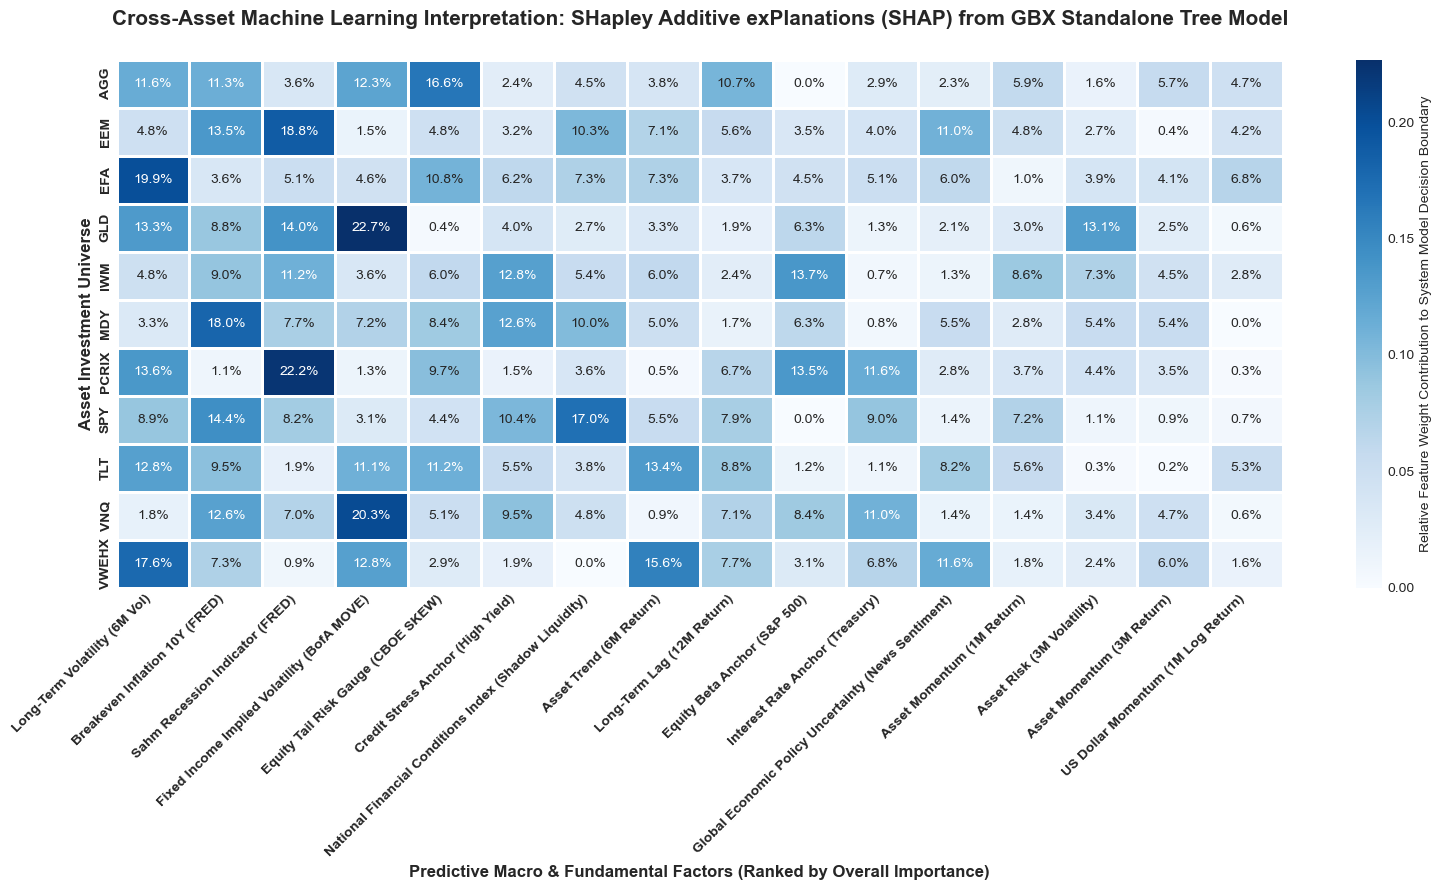

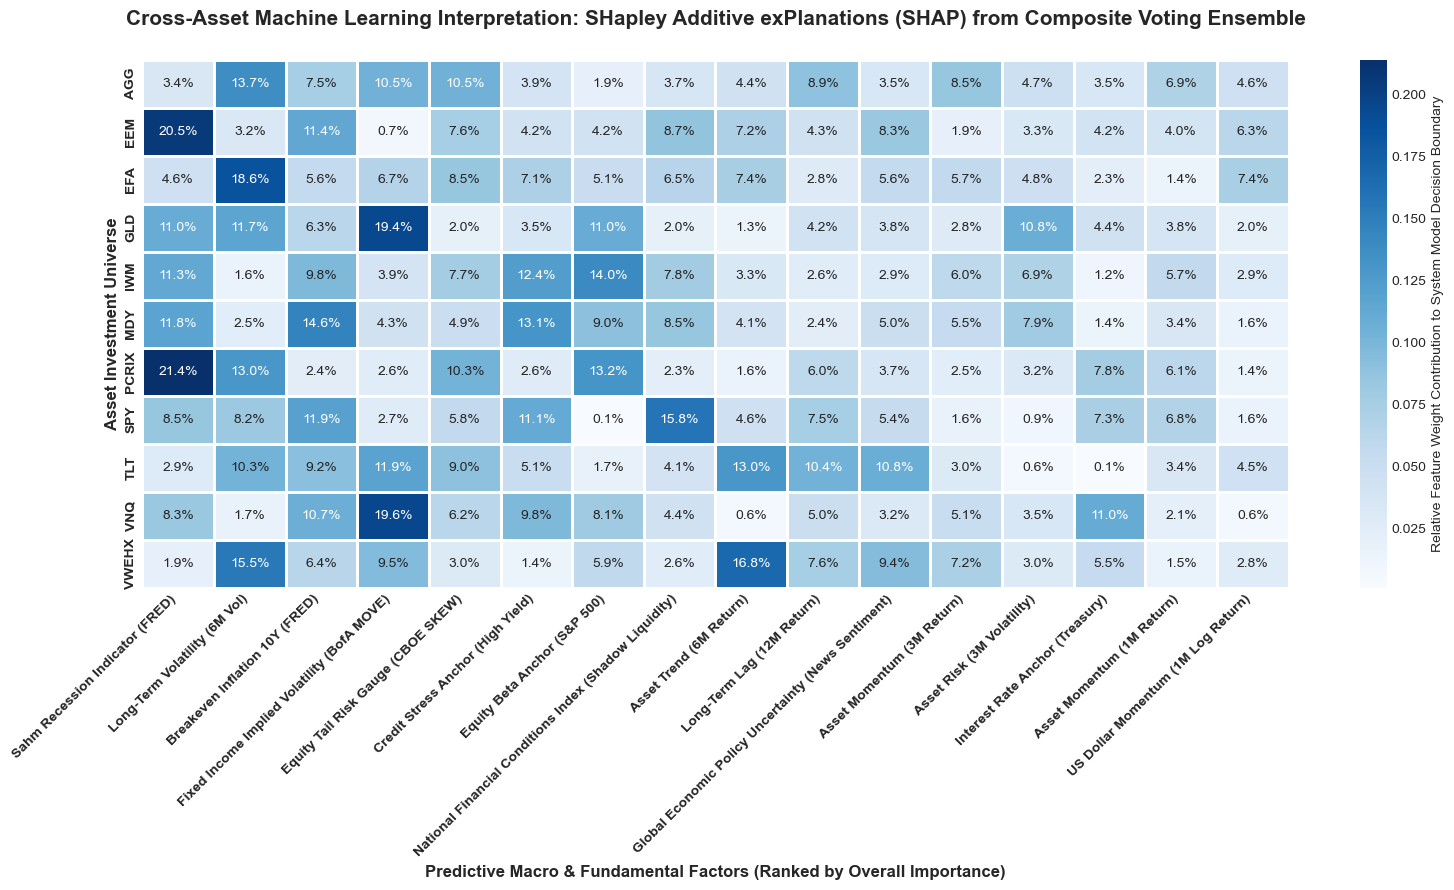


[SUCCESS] Global feature interpretation complete for both pipeline modes!
 -> Transformed standalone tree breakdown saved to: 'GBX_SHAP_Matrix.png'
 -> Transformed structural ensemble breakdown saved to: 'Ensemble_SHAP_Matrix.png'


In [3]:
# ==============================================================================
# DUAL-MODEL GLOBAL SHAP FEATURE ATTRIBUTION MATRICES
# ==============================================================================
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

print("[INFO] Initializing Dual-Model Global SHAP Analysis Layer...")

# 1. Map Institutional Descriptive Labels to all 16 Structural Features
clean_feature_names = {
    # 9 Price and Volatility Features
    'Ret_1M': 'Asset Momentum (1M Return)',
    'Ret_3M': 'Asset Momentum (3M Return)',
    'Ret_6M': 'Asset Trend (6M Return)',
    'Ret_12M': 'Long-Term Lag (12M Return)',
    'Vol_3M': 'Asset Risk (3M Volatility)',
    'Vol_6M': 'Long-Term Volatility (6M Vol)',
    'Macro_SPY_3M': 'Equity Beta Anchor (S&P 500)',
    'Macro_TLT_3M': 'Interest Rate Anchor (Treasury)',
    'Macro_VWEHX_3M': 'Credit Stress Anchor (High Yield)',
    # 7 Alternative Macro Features
    'SAHMREALTIME': 'Sahm Recession Indicator (FRED)',
    'T10YIE': 'Breakeven Inflation 10Y (FRED)',
    'GEPUCURRENT': 'Global Economic Policy Uncertainty (News Sentiment)',
    'NFCI': 'National Financial Conditions Index (Shadow Liquidity)',
    '^SKEW': 'Equity Tail Risk Gauge (CBOE SKEW)',
    '^MOVE': 'Fixed Income Implied Volatility (BofA MOVE)',
    'USD_Log_Ret_1M': 'US Dollar Momentum (1M Log Return)'
}

# 2. Allocate Dataframes for both models across the 16-feature space
feature_names_raw = features_dict[assets_list[0]].columns
global_shap_gbx = pd.DataFrame(index=assets_list, columns=feature_names_raw, dtype=float)
global_shap_ensemble = pd.DataFrame(index=assets_list, columns=feature_names_raw, dtype=float)

# ------------------------------------------------------------------------------
# EXTRACTION CORE: FIT REPS AND DECONSTRUCT MODEL LOGIC PER ASSET
# ------------------------------------------------------------------------------
for asset in assets_list:
    # Use the full valid historical series up to the edge of the forward boundary
    valid_idx = targets_bin_dict[asset].dropna().index
    X_sample = features_dict[asset].loc[valid_idx]
    y_sample = targets_bin_dict[asset].loc[valid_idx]
    
    # --- MODEL A: STANDALONE GRADIENT BOOSTING BASELINE ---
    model_gbx = GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42)
    model_gbx.fit(X_sample, y_sample)
    
    explainer_gbx = shap.TreeExplainer(model_gbx)
    shap_vals_gbx = explainer_gbx.shap_values(X_sample)
    
    # Shape Safety Handling for Binary Trees
    if isinstance(shap_vals_gbx, list): shap_vals_gbx = shap_vals_gbx[1]
    elif len(shap_vals_gbx.shape) == 3: shap_vals_gbx = shap_vals_gbx[:, :, 1]
    global_shap_gbx.loc[asset] = np.abs(shap_vals_gbx).mean(axis=0)
    
    # --- MODEL B: COMPOSITE ENSEMBLE ---
    clf_log = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    clf_rf = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=42)
    clf_xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
    
    model_ens = VotingClassifier(
        estimators=[('LogReg', clf_log), ('RandomForest', clf_rf), ('XGBoost', clf_xgb)],
        voting='soft', weights=[0.2, 0.4, 0.4]
    )
    model_ens.fit(X_sample, y_sample)
    
    # Extract tree-based drivers directly to calculate additive feature attributions
    rf_sub_model = model_ens.named_estimators_['RandomForest']
    xgb_sub_model = model_ens.named_estimators_['XGBoost']
    
    shap_rf = shap.TreeExplainer(rf_sub_model).shap_values(X_sample)
    if isinstance(shap_rf, list): shap_rf = shap_rf[1]
    elif len(shap_rf.shape) == 3: shap_rf = shap_rf[:, :, 1]
        
    shap_xgb = shap.TreeExplainer(xgb_sub_model).shap_values(X_sample)
    if isinstance(shap_xgb, list): shap_xgb = shap_xgb[1]
    elif len(shap_xgb.shape) == 3: shap_xgb = shap_xgb[:, :, 1]
        
    # Combine tree-based SHAP matrices proportionally to map the ensemble's decision paths
    blended_tree_shap = (0.50 * np.abs(shap_rf)) + (0.50 * np.abs(shap_xgb))
    global_shap_ensemble.loc[asset] = blended_tree_shap.mean(axis=0)

# 3. Normalize Importance Matrices to Relative Percentage Metrics
global_shap_gbx_norm = global_shap_gbx.div(global_shap_gbx.sum(axis=1), axis=0).rename(columns=clean_feature_names)
global_shap_ens_norm = global_shap_ensemble.div(global_shap_ensemble.sum(axis=1), axis=0).rename(columns=clean_feature_names)

# ------------------------------------------------------------------------------
# INSTITUTIONAL VISUALIZATION ENGINE
# ------------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')
matrices_to_plot = [
    (global_shap_gbx_norm, 'GBX Standalone Tree Model', 'GBX_SHAP_Matrix.png'),
    (global_shap_ens_norm, 'Composite Voting Ensemble', 'Ensemble_SHAP_Matrix.png')
]

for norm_df, title_label, file_save_name in matrices_to_plot:
    # Sort columns dynamically from highest mean importance to lowest across all assets
    ordered_features = norm_df.mean().sort_values(ascending=False).index
    plot_df = norm_df[ordered_features]
    
    plt.figure(figsize=(16, 9))
    sns.heatmap(plot_df, 
                annot=True, 
                fmt=".1%", 
                cmap="Blues", 
                cbar_kws={'label': 'Relative Feature Weight Contribution to System Model Decision Boundary'},
                linewidths=1, 
                linecolor='white')
    
    plt.title(f"Cross-Asset Machine Learning Interpretation: SHapley Additive exPlanations (SHAP) from {title_label}", 
              fontsize=15, fontweight='bold', pad=25)
    plt.ylabel("Asset Investment Universe", fontsize=12, fontweight='bold')
    plt.xlabel("Predictive Macro & Fundamental Factors (Ranked by Overall Importance)", fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right', fontweight='bold', fontsize=10)
    plt.yticks(fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    #plt.savefig(file_save_name, dpi=300, bbox_inches='tight')
    plt.show()

print("\n[SUCCESS] Global feature interpretation complete for both pipeline modes!")
#print(" -> Transformed standalone tree breakdown saved to: 'GBX_SHAP_Matrix.png'")
#print(" -> Transformed structural ensemble breakdown saved to: 'Ensemble_SHAP_Matrix.png'")

[INFO] Generating Dual-Model Strategic Intelligence Heatmaps...


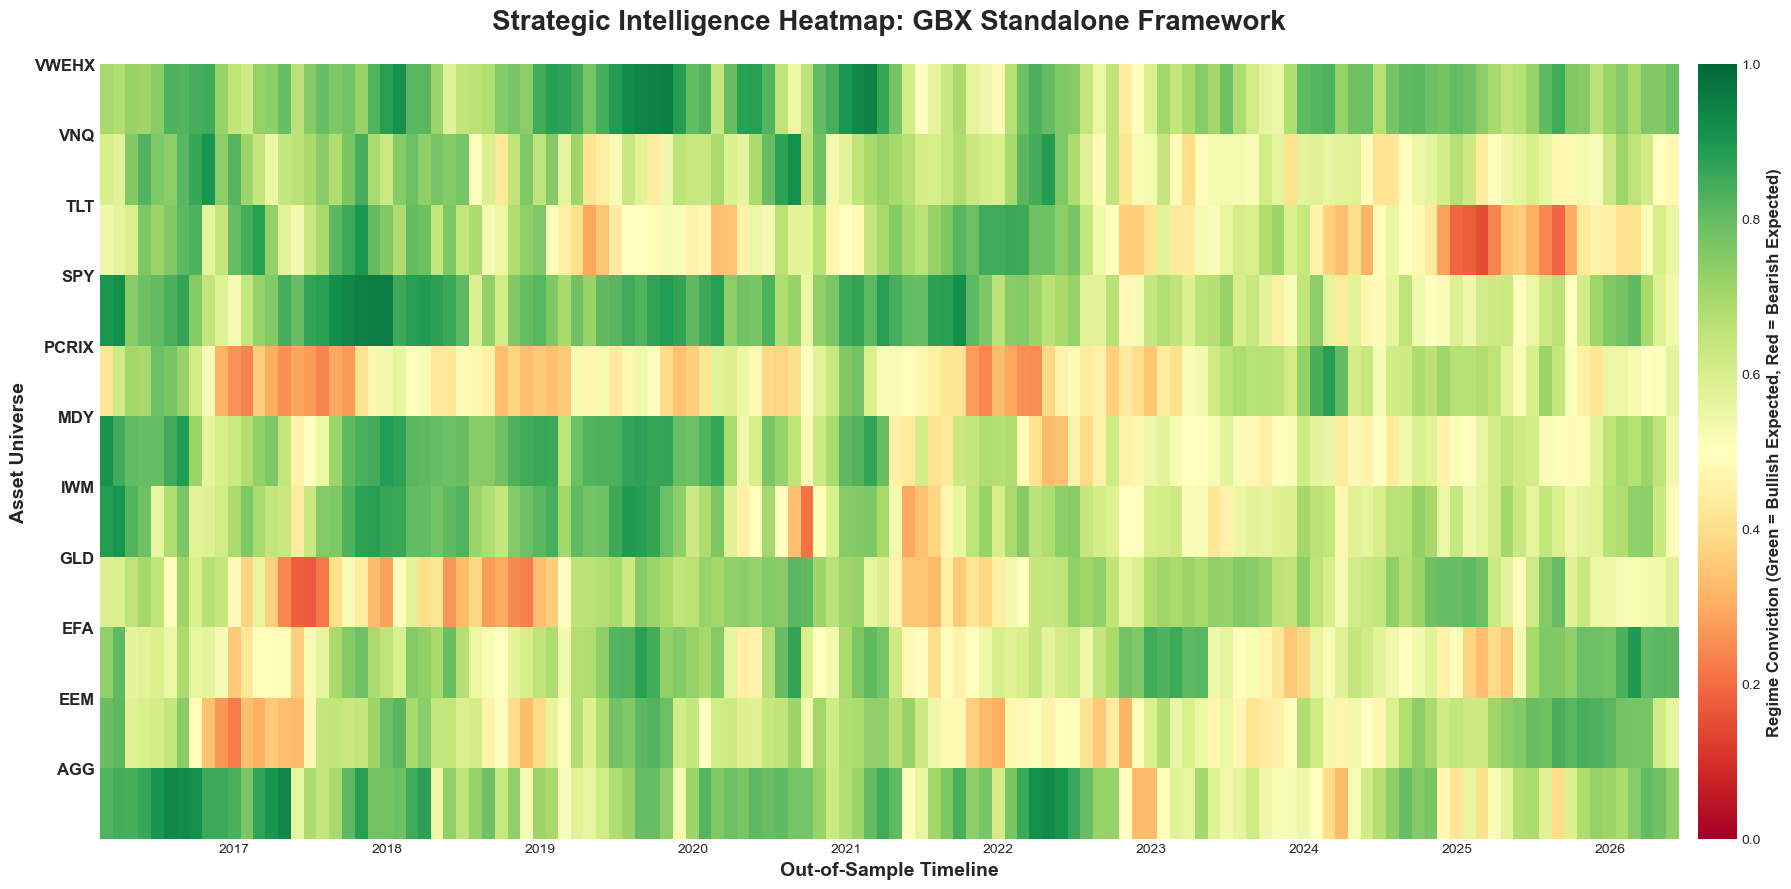

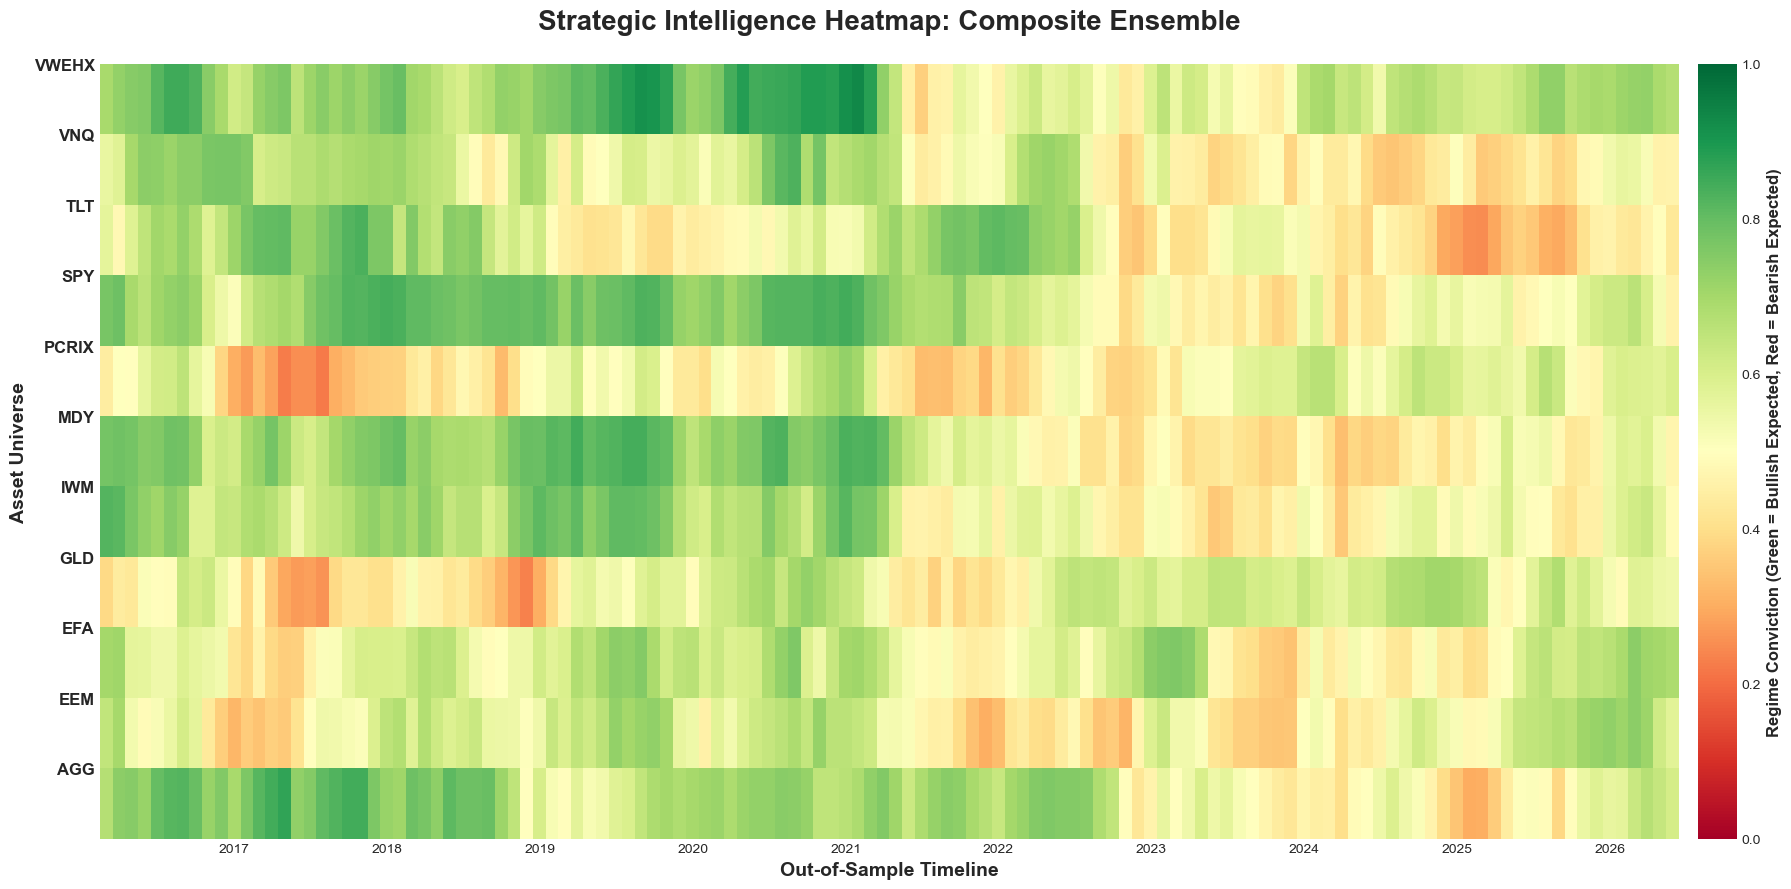


[SUCCESS] Regime Heatmaps generated and saved successfully!


In [11]:
# ==============================================================================
# DUAL-MODEL CROSS-ASSET REGIME INTELLIGENCE HEATMAPS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

print("[INFO] Generating Dual-Model Strategic Intelligence Heatmaps...")

# Define the models and their respective data files
heatmap_configs = [
    {
        'file': 'gbx_regime_probabilities.csv',
        'title': 'Strategic Intelligence Heatmap: GBX Standalone Framework',
        'save_path': 'Chart_6_GBX_Regime_Heatmap.png'
    },
    {
        'file': 'ensemble_regime_probabilities.csv',
        'title': 'Strategic Intelligence Heatmap: Composite Ensemble',
        'save_path': 'Chart_7_Ensemble_Regime_Heatmap.png'
    }
]

for config in heatmap_configs:
    if not os.path.exists(config['file']):
        print(f"[WARNING] File '{config['file']}' not found. Please run the prediction engine first.")
        continue
        
    # 1. Load the raw probability history
    raw_prob_history = pd.read_csv(config['file'], index_col=0, parse_dates=True)
    
    # 2. Apply a 3-month EWMA to smooth visual noise and expose structural regimes
    smoothed_probs = raw_prob_history.ewm(span=3).mean().dropna()
    
    # Sort columns alphabetically for a structured visual hierarchy
    sorted_assets = sorted(raw_prob_history.columns)
    plot_data = smoothed_probs[sorted_assets].T
    
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(20, 9))
    
    # High-fidelity Heatmap using pcolormesh
    c = ax.pcolormesh(plot_data.columns, np.arange(len(sorted_assets)), plot_data.values, 
                      cmap='RdYlGn', shading='auto', vmin=0, vmax=1)
    
    # Institutional Formatting
    ax.set_yticks(np.arange(len(sorted_assets)) + 0.5)
    ax.set_yticklabels(sorted_assets, fontweight='bold', fontsize=12)
    
    ax.set_title(config['title'], fontsize=20, fontweight='bold', pad=25)
    ax.set_xlabel('Out-of-Sample Timeline', fontsize=14, fontweight='bold')
    ax.set_ylabel('Asset Universe', fontsize=14, fontweight='bold')
    
    # Colorbar with specific labeling
    cbar = fig.colorbar(c, ax=ax, pad=0.01)
    cbar.set_label('Regime Conviction (Green = Bullish Expected, Red = Bearish Expected)', 
                   fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    #plt.savefig(config['save_path'], dpi=300, bbox_inches='tight')
    plt.show()

print("\n[SUCCESS] Regime Heatmaps generated and saved successfully!")

In [12]:
# ==============================================================================
# PORTFOLIO ENGINE
# ==============================================================================
import pandas as pd
import numpy as np
import scipy.optimize as sco
import warnings
warnings.filterwarnings("ignore")

# Ensure pandas prints the wide matrix cleanly without line-wrapping
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("[INFO] Initializing Endogenous Data Ingestion...")

# ------------------------------------------------------------------------------
# 0. DATA INGESTION 
# ------------------------------------------------------------------------------
# Define the target folder
data_folder = "Data"

# Route the price dataset through the Data folder
daily_prices = pd.read_csv(os.path.join(data_folder, "Portfolio Asset Price Dataset.csv"), index_col=0, parse_dates=True)
daily_returns = daily_prices.pct_change().dropna()
monthly_returns = daily_prices.resample('ME').last().pct_change().dropna()

assets_list = [c for c in monthly_returns.columns if c != 'VFISX']
excess_monthly = monthly_returns.drop(columns=['VFISX'], errors='ignore').sub(
    monthly_returns['VFISX'] if 'VFISX' in monthly_returns.columns else 0.0, axis=0
)

# Route the ensemble probabilities through the Data folder
ensemble_probs_df = pd.read_csv(os.path.join(data_folder, 'ensemble_regime_probabilities.csv'), index_col=0, parse_dates=True)
oos_dates = ensemble_probs_df.index.intersection(excess_monthly.index)

# ------------------------------------------------------------------------------
# 1. CORE PARAMETERS
# ------------------------------------------------------------------------------
CONVICTION_DEADBAND = 0.10
TURNOVER_THRESHOLD = 0.05
alpha_scalar = 0.45 
IC_ASSUMED = 0.15 
ACTIVE_RISK = 2.0 
mo_vol_tgt = 0.10 / np.sqrt(12) # 10% annual volatility target
beta = 0.8 # Portfolio Inertia

def erc_objective(w, cov, budgets):
    port_var = np.dot(w.T, np.dot(cov, w))
    marginal_contrib = np.dot(cov, w)
    component_contrib = w * marginal_contrib
    target_contrib = port_var * budgets
    return np.sum(np.square(component_contrib - target_contrib)) * 1e9

# ------------------------------------------------------------------------------
# 2. ALLOCATION ENGINE (UNIVERSAL 11-ASSET)
# ------------------------------------------------------------------------------
def run_allocation_engine(apply_filters=True):
    n_assets = len(assets_list)
    excess_univ = excess_monthly[assets_list]
    
    alloc_keys = ['MVO_LO', 'MVO_LS', 'ERC', 'VRP', 'PURE_LO', 'PURE_LS']
    w_base = {k: pd.DataFrame(index=oos_dates, columns=assets_list, dtype=float) for k in alloc_keys}
    w_ml = {k: pd.DataFrame(index=oos_dates, columns=assets_list, dtype=float) for k in alloc_keys}
    w_prev_ml = {k: np.ones(n_assets)/n_assets for k in alloc_keys}
    
    # Unconstrained strategies initialize their baseline state to cash (zeros)
    w_prev_ml['PURE_LS'] = np.zeros(n_assets)
    
    bnds_ls = [(-1.0, 1.0)] * n_assets
    bnds_lo = [(0.0, 1.0)] * n_assets
    
    for t in oos_dates:
        train_rets = excess_univ.loc[:t].iloc[-61:-1]
        if len(train_rets) < 60: continue
            
        mu_hist, cov, std_hist = train_rets.mean().values, train_rets.cov().values, train_rets.std().values
        w_inv_vol = (1.0 / std_hist) / np.sum(1.0 / std_hist)
        
        # Constrained Optimization Rules (Sum-To-One)
        mvo_cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
                    {'type': 'ineq', 'fun': lambda w: (mo_vol_tgt**2) - np.dot(w.T, np.dot(cov, w))}]
        
        # Unconstrained Optimization Rules (No Budget Constraint, Bounds Limited Only by Vol and Box)
        mvo_uc_cons = [{'type': 'ineq', 'fun': lambda w: (mo_vol_tgt**2) - np.dot(w.T, np.dot(cov, w))}]
        
        # --- 1. ORIGINAL BASELINES (No ML) ---
        res_mvo_lo_base = sco.minimize(lambda w: -np.dot(mu_hist, w), np.ones(n_assets)/n_assets, method='SLSQP', bounds=bnds_lo, constraints=mvo_cons)
        w_base['MVO_LO'].loc[t] = res_mvo_lo_base.x if res_mvo_lo_base.success else np.ones(n_assets)/n_assets

        res_mvo_ls_base = sco.minimize(lambda w: -np.dot(mu_hist, w), np.ones(n_assets)/n_assets, method='SLSQP', bounds=bnds_ls, constraints=mvo_cons)
        w_base['MVO_LS'].loc[t] = res_mvo_ls_base.x if res_mvo_ls_base.success else np.ones(n_assets)/n_assets

        res_erc_base = sco.minimize(erc_objective, np.ones(n_assets)/n_assets, args=(cov, np.ones(n_assets)/n_assets), method='SLSQP', bounds=bnds_lo, constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}])
        w_base['ERC'].loc[t] = res_erc_base.x if res_erc_base.success else np.ones(n_assets)/n_assets
        
        w_base['VRP'].loc[t] = w_inv_vol
        w_base['PURE_LO'].loc[t] = np.ones(n_assets)/n_assets 
        w_base['PURE_LS'].loc[t] = np.zeros(n_assets) 

        # --- 2. ML EXTRACTION & SAFETY MASK ---
        raw_probs = ensemble_probs_df.loc[t][assets_list].values
        
        if apply_filters:
            probs_curr = np.ones(n_assets) * 0.50 
            for i, p in enumerate(raw_probs):
                if abs(p - 0.50) >= CONVICTION_DEADBAND: 
                    probs_curr[i] = p
        else:
            probs_curr = raw_probs.copy()
                
        z_scores = (probs_curr - 0.50) * 2.0 
        alpha_scores = IC_ASSUMED * np.sqrt(np.diag(cov)) * z_scores * ACTIVE_RISK
        
        # --- 3. ML INTEGRATIONS (With Friction Constraints) ---
        # MVO Long-Only (Strictly Constrained Budget)
        res_mvo_lo_ml = sco.minimize(lambda w: -np.dot(mu_hist + alpha_scores, w), np.ones(n_assets)/n_assets, method='SLSQP', bounds=bnds_lo, constraints=mvo_cons)
        tgt_mvo_lo = beta * (res_mvo_lo_ml.x if res_mvo_lo_ml.success else np.ones(n_assets)/n_assets) + (1.0 - beta) * w_prev_ml['MVO_LO']
        w_ml['MVO_LO'].loc[t] = tgt_mvo_lo if np.sum(np.abs(tgt_mvo_lo - w_prev_ml['MVO_LO'])) > TURNOVER_THRESHOLD else w_prev_ml['MVO_LO']
        w_prev_ml['MVO_LO'] = w_ml['MVO_LO'].loc[t].values

        # MVO Long-Short (Strictly Constrained Budget, 100% Net Exposure)
        res_mvo_ls_ml = sco.minimize(lambda w: -np.dot(mu_hist + alpha_scores, w), np.ones(n_assets)/n_assets, method='SLSQP', bounds=bnds_ls, constraints=mvo_cons)
        tgt_mvo_ls = beta * (res_mvo_ls_ml.x if res_mvo_ls_ml.success else np.ones(n_assets)/n_assets) + (1.0 - beta) * w_prev_ml['MVO_LS']
        w_ml['MVO_LS'].loc[t] = tgt_mvo_ls if np.sum(np.abs(tgt_mvo_ls - w_prev_ml['MVO_LS'])) > TURNOVER_THRESHOLD else w_prev_ml['MVO_LS']
        w_prev_ml['MVO_LS'] = w_ml['MVO_LS'].loc[t].values

        # ERC
        exp_z = np.exp(z_scores * 1.5)
        risk_budgets = exp_z / np.sum(exp_z)
        res_erc_ml = sco.minimize(erc_objective, np.ones(n_assets)/n_assets, args=(cov, risk_budgets), method='SLSQP', bounds=bnds_lo, constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}])
        tgt_erc = beta * (res_erc_ml.x if res_erc_ml.success else np.ones(n_assets)/n_assets) + (1.0 - beta) * w_prev_ml['ERC']
        w_ml['ERC'].loc[t] = tgt_erc if np.sum(np.abs(tgt_erc - w_prev_ml['ERC'])) > TURNOVER_THRESHOLD else w_prev_ml['ERC']
        w_prev_ml['ERC'] = w_ml['ERC'].loc[t].values

        # VRP
        tgt_vrp = beta * (np.clip(w_inv_vol + (alpha_scalar * z_scores), 0, None) / np.sum(np.clip(w_inv_vol + (alpha_scalar * z_scores), 0, None))) + (1.0 - beta) * w_prev_ml['VRP']
        w_ml['VRP'].loc[t] = tgt_vrp if np.sum(np.abs(tgt_vrp - w_prev_ml['VRP'])) > TURNOVER_THRESHOLD else w_prev_ml['VRP']
        w_prev_ml['VRP'] = w_ml['VRP'].loc[t].values

        # PURE ML: Long-Only (Proportional to positive Z-Scores)
        pos_z = np.maximum(0, z_scores)
        sum_pos_z = np.sum(pos_z)
        raw_pure_lo = pos_z / sum_pos_z if sum_pos_z > 0 else np.ones(n_assets)/n_assets
        tgt_pure_lo = beta * raw_pure_lo + (1.0 - beta) * w_prev_ml['PURE_LO']
        w_ml['PURE_LO'].loc[t] = tgt_pure_lo if np.sum(np.abs(tgt_pure_lo - w_prev_ml['PURE_LO'])) > TURNOVER_THRESHOLD else w_prev_ml['PURE_LO']
        w_prev_ml['PURE_LO'] = w_ml['PURE_LO'].loc[t].values

        # PURE ML: Unconstrained Bounded [-1, 1] (Global Macro CTA Sleeve)
        raw_pure_ls = np.clip(z_scores, -1.0, 1.0)
        tgt_pure_ls = beta * raw_pure_ls + (1.0 - beta) * w_prev_ml['PURE_LS']
        w_ml['PURE_LS'].loc[t] = tgt_pure_ls if np.sum(np.abs(tgt_pure_ls - w_prev_ml['PURE_LS'])) > TURNOVER_THRESHOLD else w_prev_ml['PURE_LS']
        w_prev_ml['PURE_LS'] = w_ml['PURE_LS'].loc[t].values
        
    return w_base, w_ml

# ------------------------------------------------------------------------------
# 3. EXECUTE ENGINE RUNS
# ------------------------------------------------------------------------------
print("[INFO] Executing Architectures (Applying 10% Conviction Deadband Filter)...")
base_weights, ml_filtered_weights = run_allocation_engine(apply_filters=True)

print("[INFO] Executing Architectures (Feeding RAW Unfiltered Signals)...")
_, ml_raw_weights = run_allocation_engine(apply_filters=False)

# ------------------------------------------------------------------------------
# 4. EXPLICIT METHODOLOGY OUTPUT & METRICS ENGINE
# ------------------------------------------------------------------------------
eval_start = base_weights['ERC'].dropna().index[0]
eval_end = daily_returns.index[-1]
months_elapsed = round((eval_end - eval_start).days / 30.44)

print("\n" + "="*125)
print(f"EVALUATION TIMELINE : {eval_start.strftime('%B %Y')} to {eval_end.strftime('%B %Y')} ({months_elapsed} Months)")
print("TRANSACTION COSTS   : 10 bps (0.10%) per trade (bid/ask + slippage)")
print("="*125)

aligned_daily_rets = daily_returns.loc[eval_start:]
aligned_daily_rf = daily_returns.loc[eval_start:, 'VFISX'] if 'VFISX' in daily_returns.columns else pd.Series(0.0, index=aligned_daily_rets.index)
aligned_daily_excess_all = aligned_daily_rets.sub(aligned_daily_rf, axis=0)

def evaluate_portfolio_net(weight_df, name, normalize=True):
    w_daily = weight_df.dropna().reindex(aligned_daily_rets.index).ffill().shift(1).dropna()
    valid_excess = aligned_daily_excess_all[w_daily.columns].loc[w_daily.index]
    
    gross_excess_ret = (w_daily * valid_excess).sum(axis=1)
    gross_total_ret = gross_excess_ret + aligned_daily_rf.loc[gross_excess_ret.index]
    
    w_start = weight_df.dropna().shift(1).dropna()
    valid_monthly_raw = monthly_returns[w_start.columns].loc[w_start.index]
    
    w_drift = w_start * (1 + valid_monthly_raw)
    
    # --- SAFE BYPASS FOR UNCONSTRAINED/ELASTIC LEVERAGE STRATEGIES ---
    if normalize:
        w_drift_norm = w_drift.div(w_drift.sum(axis=1).replace(0, 1), axis=0) 
        w_target = weight_df.loc[w_drift_norm.index]
        w_target_norm = w_target.div(w_target.sum(axis=1).replace(0, 1), axis=0)
    else:
        w_drift_norm = w_drift
        w_target_norm = weight_df.loc[w_drift_norm.index]
    
    turnover_monthly = (w_target_norm - w_drift_norm).abs().sum(axis=1) / 2.0
    ann_turnover = turnover_monthly.mean() * 12
    daily_tc_drag = (ann_turnover * 2.0 * (10.0 / 10000.0)) / 252.0 
    
    net_total_ret = gross_total_ret - daily_tc_drag
    net_excess_ret = net_total_ret - aligned_daily_rf.loc[net_total_ret.index]
    
    cum_ret_gross = (1 + gross_total_ret).prod() - 1
    cum_ret_net = (1 + net_total_ret).prod() - 1
    ann_ret_gross = (1 + gross_total_ret).prod()**(252/len(gross_total_ret)) - 1
    ann_ret_net = (1 + net_total_ret).prod()**(252/len(net_total_ret)) - 1
    
    ann_vol_gross = gross_total_ret.std() * np.sqrt(252)
    ann_vol_net = net_total_ret.std() * np.sqrt(252)
    
    sharpe_gross = (gross_excess_ret.mean() / gross_excess_ret.std()) * np.sqrt(252) if gross_excess_ret.std() > 0 else 0
    sharpe_net = (net_excess_ret.mean() / net_excess_ret.std()) * np.sqrt(252) if net_excess_ret.std() > 0 else 0
    max_dd = (((1 + net_total_ret).cumprod() - (1 + net_total_ret).cumprod().cummax()) / (1 + net_total_ret).cumprod().cummax()).min()
    
    downside_returns = net_excess_ret[net_excess_ret < 0]
    downside_dev = np.sqrt((downside_returns**2).mean()) * np.sqrt(252) if len(downside_returns) > 0 else 0
    sortino_net = (net_excess_ret.mean() * 252) / downside_dev if downside_dev > 0 else 0
    calmar_net = ann_ret_net / abs(max_dd) if abs(max_dd) > 0 else 0
    
    return {
        "Strategy Variant": name, 
        "Cum. Gross": f"{cum_ret_gross*100:.2f}%",
        "Cum. Net": f"{cum_ret_net*100:.2f}%",
        "Ann. Gross": f"{ann_ret_gross*100:.2f}%",
        "Ann. Net": f"{ann_ret_net*100:.2f}%", 
        "Gross Vol": f"{ann_vol_gross*100:.2f}%",
        "Net Vol": f"{ann_vol_net*100:.2f}%", 
        "Gross Sharpe": f"{sharpe_gross:.2f}",
        "Net Sharpe": f"{sharpe_net:.2f}",
        "Net Sortino": f"{sortino_net:.2f}",
        "Net Calmar": f"{calmar_net:.2f}",
        "Max DD": f"{max_dd*100:.2f}%", 
        "Ann. Turn": f"{ann_turnover*100:.1f}%"
    }

# ------------------------------------------------------------------------------
# 5. GENERATE DISTINCT TABLES PER ARCHITECTURE
# ------------------------------------------------------------------------------
display_mapping = [
    ('MVO_LO', 'MEAN-VARIANCE OPTIMIZATION (LONG-ONLY)'),
    ('MVO_LS', 'MEAN-VARIANCE OPTIMIZATION (LONG-SHORT)'),
    ('ERC', 'EQUAL RISK CONTRIBUTION (ERC)'),
    ('VRP', 'VOLATILITY RISK PARITY (VRP)'),
    ('PURE_LO', 'PURE ML STAT-ARB (LONG-ONLY)'),
    ('PURE_LS', 'PURE ML: UNCONSTRAINED BOUNDED [-1, 1]')
]

for key, title in display_mapping:
    print(f"\n[{title}]")
    results = []
    
    # Skip drift normalization only for unconstrained cash-floating models
    should_normalize = (key not in ['PURE_LS']) 
    
    if key in ['PURE_LS']:
        base_name = "Original Cash Baseline"
    elif key == 'PURE_LO':
        base_name = "Original 1/N Baseline"
    else:
        base_name = "Original Baseline"
        
    results.append(evaluate_portfolio_net(base_weights[key], base_name, normalize=should_normalize))
    results.append(evaluate_portfolio_net(ml_raw_weights[key], "ML Ensemble (Raw Signal)", normalize=should_normalize))
    results.append(evaluate_portfolio_net(ml_filtered_weights[key], "ML Ensemble (Filtered Signal)", normalize=should_normalize))
    
    df_results = pd.DataFrame(results).set_index("Strategy Variant")
    print(df_results.to_string())
    print("-" * 125)

[INFO] Initializing Endogenous Data Ingestion...
[INFO] Executing Architectures (Applying 10% Conviction Deadband Filter)...
[INFO] Executing Architectures (Feeding RAW Unfiltered Signals)...

EVALUATION TIMELINE : February 2016 to May 2026 (122 Months)
TRANSACTION COSTS   : 10 bps (0.10%) per trade (bid/ask + slippage)

[MEAN-VARIANCE OPTIMIZATION (LONG-ONLY)]
                              Cum. Gross Cum. Net Ann. Gross Ann. Net Gross Vol Net Vol Gross Sharpe Net Sharpe Net Sortino Net Calmar   Max DD Ann. Turn
Strategy Variant                                                                                                                                         
Original Baseline                232.48%  221.64%     12.54%   12.17%    13.96%  13.96%         0.80       0.78        0.71       0.43  -28.53%    163.1%
ML Ensemble (Raw Signal)         265.85%  250.01%     13.60%   13.11%    13.89%  13.89%         0.87       0.84        0.77       0.46  -28.50%    217.6%
ML Ensemble (Filtere

[INFO] Computing Asset-Level Volatility Contributions and Weights...


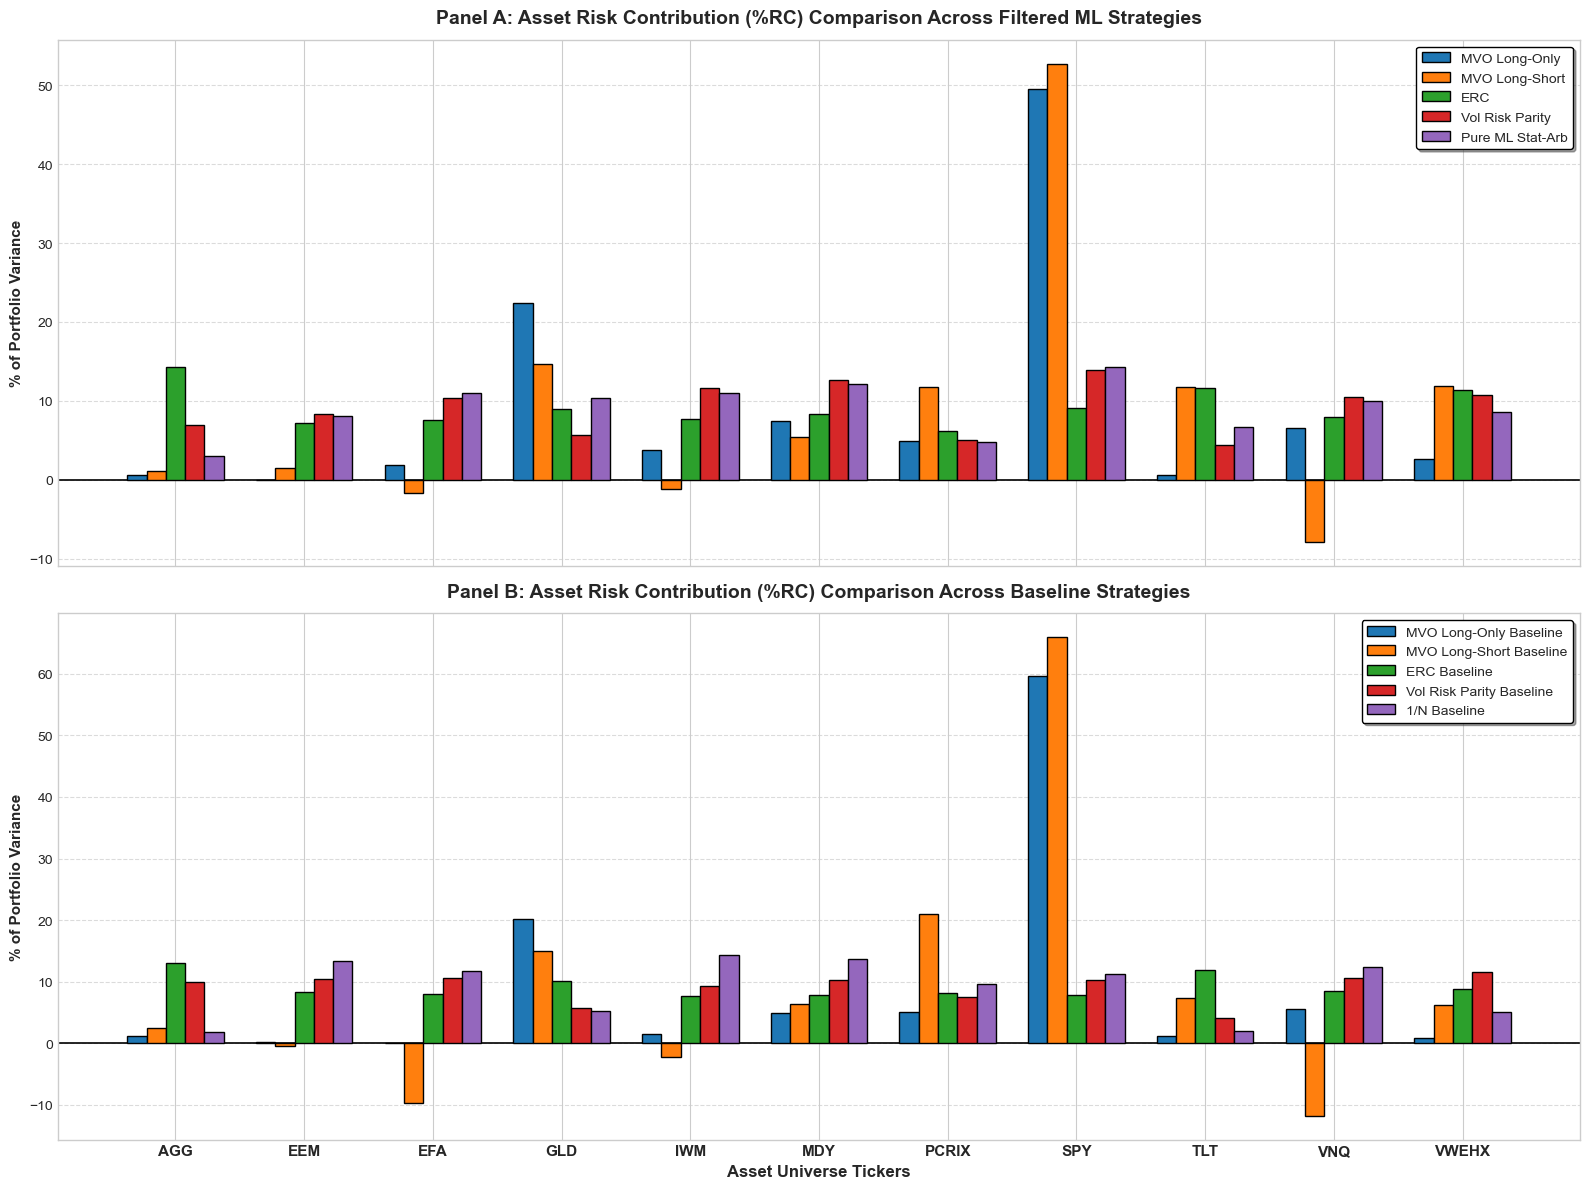

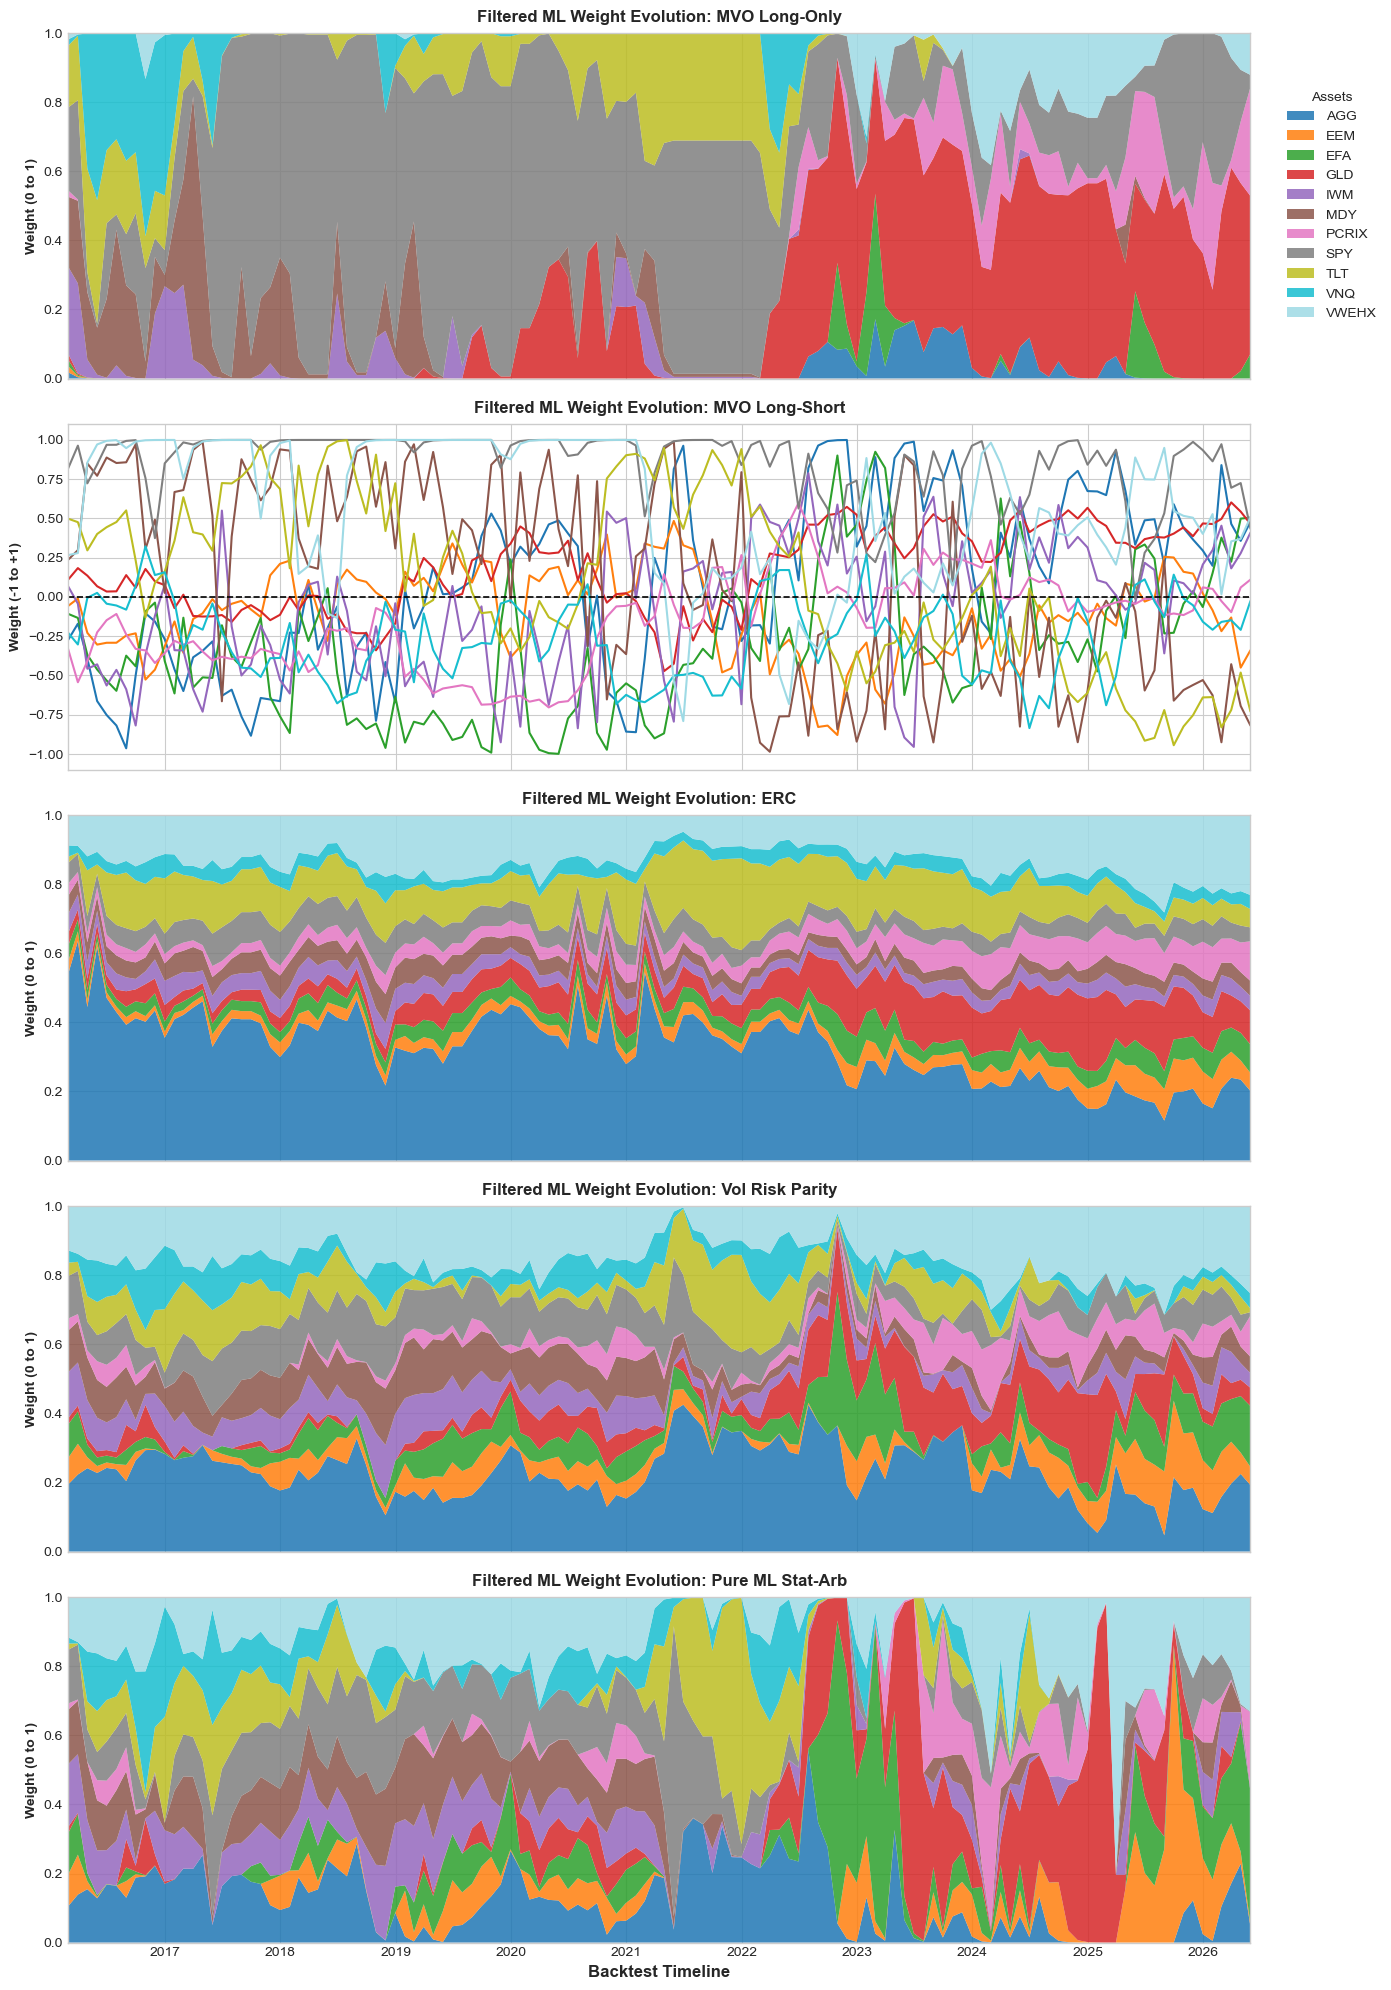

In [3]:
# ==============================================================================
# RISK DECOMPOSITION
# ==============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# 0. SAFETY CHECK: RE-GENERATE DATA IF KERNEL RESTARTED
# ==============================================================================
if 'base_weights' not in locals() or 'ml_filtered_weights' not in locals():
    print("[INFO] Portfolio weights not found in memory. Re-running the V6 Allocation Engine...")
    try:
        base_weights, ml_filtered_weights = run_allocation_engine(apply_filters=True)
        print("[SUCCESS] Engine re-run complete. Weights restored.")
    except NameError:
        raise RuntimeError("ERROR: 'run_allocation_engine' is not defined. Please scroll up and run the massive 'V6 - UNCONSTRAINED MVO' cell first so Python knows how to run the backtest.")

if 'monthly_returns' not in locals():
    print("[INFO] Restoring monthly returns from daily prices...")
    monthly_returns = daily_prices.resample('ME').last().pct_change().dropna()

# ==============================================================================
# 1. COMPUTE ASSET-LEVEL VOLATILITY CONTRIBUTIONS (%RC)
# ==============================================================================
print("[INFO] Computing Asset-Level Volatility Contributions and Weights...")

assets_list = [c for c in monthly_returns.columns if c != 'VFISX']
alloc_keys = ['MVO_LO', 'MVO_LS', 'ERC', 'VRP', 'PURE_LO'] 
oos_dates = base_weights['MVO_LO'].dropna().index

# Initialize Storage for Asset Volatility Contribution
rc_base = {k: pd.DataFrame(index=oos_dates, columns=assets_list, dtype=float) for k in alloc_keys}
rc_filt = {k: pd.DataFrame(index=oos_dates, columns=assets_list, dtype=float) for k in alloc_keys}

# Point-in-Time Asset Volatility Contribution (%RC) Calculation
for t in oos_dates:
    train_rets = monthly_returns[assets_list].loc[:t].iloc[-61:-1]
    if len(train_rets) < 60: 
        continue
    cov_matrix = train_rets.cov().values
    
    for key in alloc_keys:
        # Baseline Risk Contribution
        w_b = base_weights[key].loc[t].values
        if key == 'PURE_LO': # Force PURE_LO baseline to be 1/N 
            w_b = np.ones(len(assets_list)) / len(assets_list)
            
        port_var_b = np.dot(w_b.T, np.dot(cov_matrix, w_b))
        if port_var_b > 1e-10:
            rc_base[key].loc[t] = (w_b * np.dot(cov_matrix, w_b)) / port_var_b
        else:
            rc_base[key].loc[t] = np.zeros(len(assets_list))
            
        # Filtered ML Risk Contribution
        w_f = ml_filtered_weights[key].loc[t].values
        port_var_f = np.dot(w_f.T, np.dot(cov_matrix, w_f))
        if port_var_f > 1e-10:
            rc_filt[key].loc[t] = (w_f * np.dot(cov_matrix, w_f)) / port_var_f
        else:
            rc_filt[key].loc[t] = np.zeros(len(assets_list))

mean_rc_base = {k: rc_base[k].mean() * 100 for k in alloc_keys}
mean_rc_filt = {k: rc_filt[k].mean() * 100 for k in alloc_keys}

# ==============================================================================
# VISUALIZATION A: ASSET VOLATILITY CONTRIBUTION (%RC) DUAL-PANEL
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

x_indices = np.arange(len(assets_list))
bar_width = 0.15 

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
labels = ['MVO Long-Only', 'MVO Long-Short', 'ERC', 'Vol Risk Parity', 'Pure ML Stat-Arb']

# --- PANEL A: FILTERED ML VERSIONS ---
for i, key in enumerate(alloc_keys):
    offset = (i - 2) * bar_width
    ax1.bar(x_indices + offset, mean_rc_filt[key], bar_width, label=labels[i], color=colors[i], edgecolor='black', zorder=3)

ax1.set_title('Panel A: Asset Risk Contribution (%RC) Comparison Across Filtered ML Strategies', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('% of Portfolio Variance', fontsize=11, fontweight='bold')
ax1.axhline(0, color='black', linewidth=1.2)
ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax1.legend(loc='upper right', frameon=True, shadow=True, edgecolor='black')

# --- PANEL B: BASELINE VERSIONS ---
for i, key in enumerate(alloc_keys):
    offset = (i - 2) * bar_width
    label_b = "1/N Baseline" if key == 'PURE_LO' else f"{labels[i]} Baseline"
    ax2.bar(x_indices + offset, mean_rc_base[key], bar_width, label=label_b, color=colors[i], edgecolor='black', zorder=3)

ax2.set_title('Panel B: Asset Risk Contribution (%RC) Comparison Across Baseline Strategies', fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('% of Portfolio Variance', fontsize=11, fontweight='bold')
ax2.set_xlabel('Asset Universe Tickers', fontsize=12, fontweight='bold')
ax2.axhline(0, color='black', linewidth=1.2)
ax2.set_xticks(x_indices)
ax2.set_xticklabels(assets_list, fontsize=11, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax2.legend(loc='upper right', frameon=True, shadow=True, edgecolor='black')

plt.tight_layout()
#plt.savefig('Asset_Volatility_Contribution_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# VISUALIZATION B: 5-PANEL PORTFOLIO WEIGHT EVOLUTION (FILTERED SIGNALS)
# ==============================================================================
fig2, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
asset_colors = plt.cm.tab20(np.linspace(0, 1, len(assets_list)))

for idx, (ax, key) in enumerate(zip(axes, alloc_keys)):
    w_df = ml_filtered_weights[key].dropna()
    
    if key == 'MVO_LS':
        for j, asset in enumerate(assets_list):
            ax.plot(w_df.index, w_df[asset], label=asset, color=asset_colors[j], linewidth=1.5)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
        ax.set_ylabel('Weight (-1 to +1)', fontsize=10, fontweight='bold')
    else:
        ax.stackplot(w_df.index, w_df.T, labels=assets_list, colors=asset_colors, alpha=0.85)
        ax.set_ylabel('Weight (0 to 1)', fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.0)
        
    ax.set_title(f'Filtered ML Weight Evolution: {labels[idx]}', fontsize=12, fontweight='bold', pad=8)
    ax.margins(x=0)
    
    if idx == 0:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title="Assets", fontsize=10, edgecolor='black')

plt.xlabel('Backtest Timeline', fontsize=12, fontweight='bold')
plt.tight_layout()
#plt.savefig('Filtered_Weights_Evolution_5Panel.png', dpi=300, bbox_inches='tight')
plt.show()

#print("[SUCCESS] Exported 'Asset_Volatility_Contribution_Matrix.png' and 'Filtered_Weights_Evolution_5Panel.png'")

[INFO] Computing Regime-Conditional Performance Across All Architectures...
[INFO] Timeline Split -> Expansion/Risk-On: 87 Months | Crisis/Stress: 37 Months


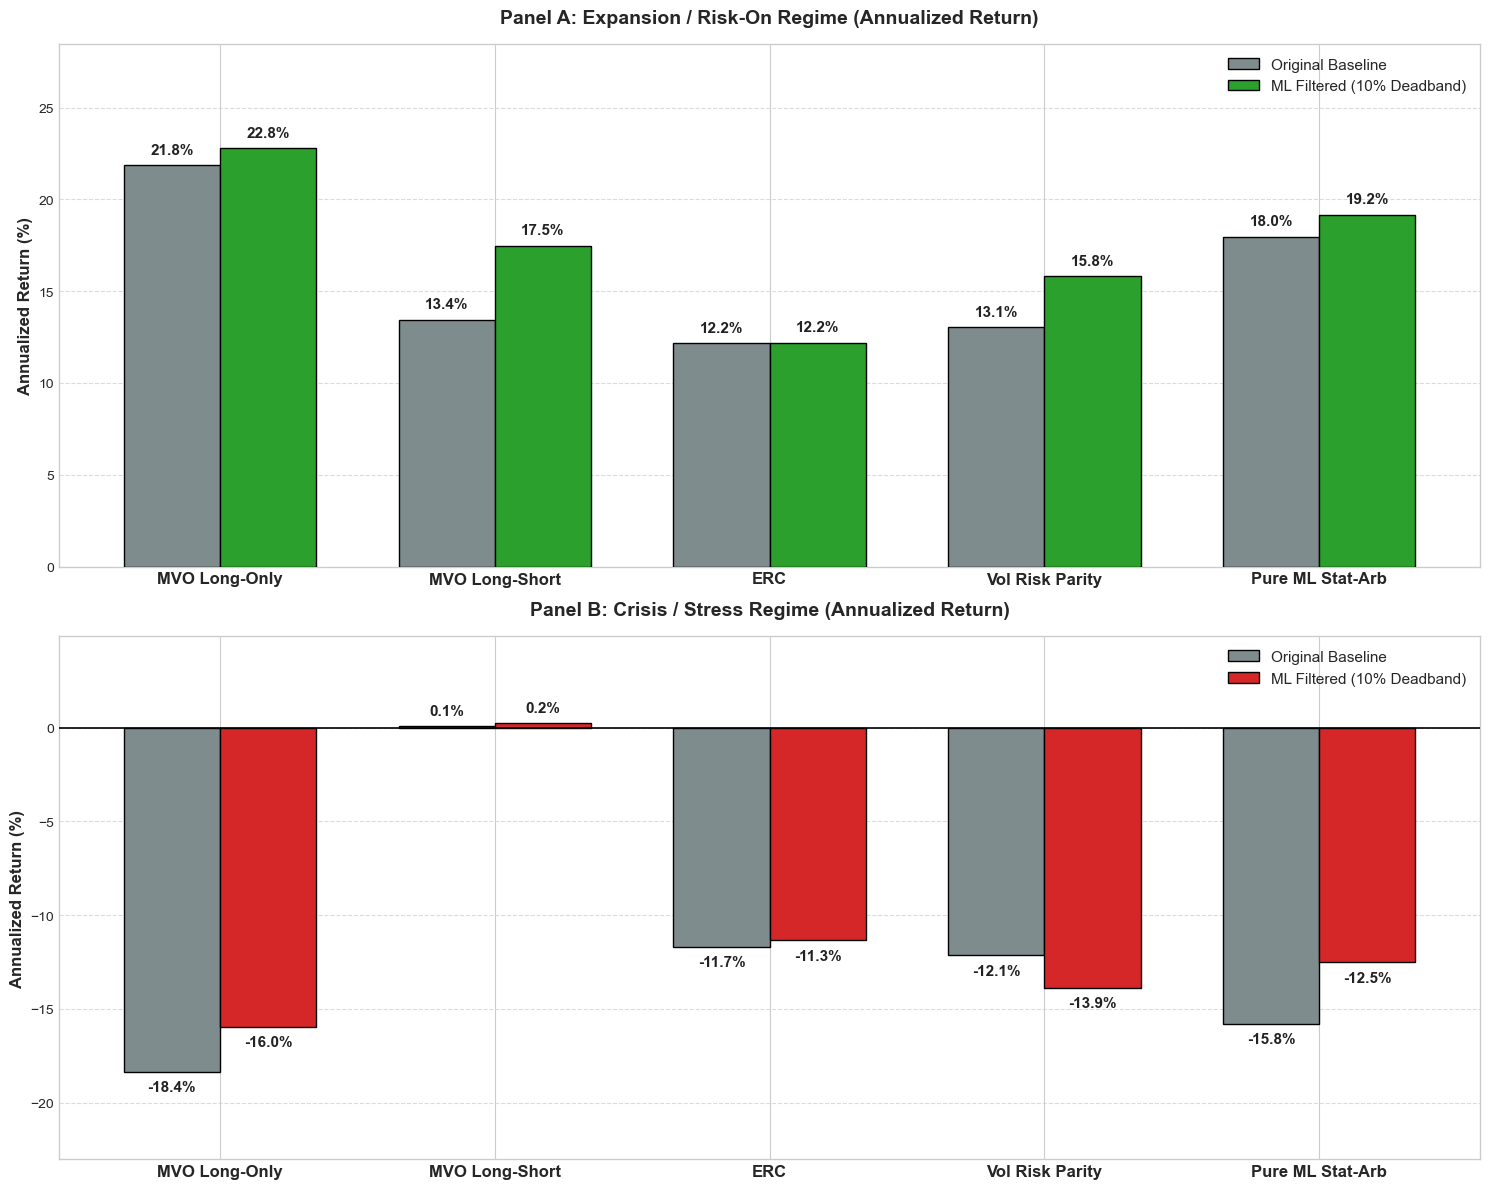


[SUCCESS] Exported 'Regime_Conditional_Returns_Clean.png'


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("[INFO] Computing Regime-Conditional Performance Across All Architectures...")

# 1. Pull data guaranteed to be in memory
oos_dates = base_weights['MVO_LO'].dropna().index
assets_list = [c for c in excess_monthly.columns if c != 'VFISX']
oos_returns = excess_monthly[assets_list].loc[oos_dates]

# ==============================================================================
# 2. ENDOGENOUS REGIME PROXY (Replacing factors_df)
# ==============================================================================
# We define a "Crisis" strictly using internal market stress indicators:
# Stress = High Yield Credit (VWEHX) is negative OR Large Cap Equity (SPY) is negative.
spy_3m = excess_monthly['SPY'].rolling(window=3, min_periods=1).sum().loc[oos_dates]
vwehx_3m = excess_monthly['VWEHX'].rolling(window=3, min_periods=1).sum().loc[oos_dates]

crisis_mask = (spy_3m < 0.0) | (vwehx_3m < 0.0)
expansion_mask = ~crisis_mask

print(f"[INFO] Timeline Split -> Expansion/Risk-On: {expansion_mask.sum()} Months | Crisis/Stress: {crisis_mask.sum()} Months")

# ==============================================================================
# 3. METRICS CALCULATION
# ==============================================================================
alloc_keys = ['MVO_LO', 'MVO_LS', 'ERC', 'VRP', 'PURE_LO']
labels = ['MVO Long-Only', 'MVO Long-Short', 'ERC', 'Vol Risk Parity', 'Pure ML Stat-Arb']

base_exp_rets, filt_exp_rets = [], []
base_cri_rets, filt_cri_rets = [], []

def get_regime_ann_ret(weights_dict, key, mask, is_pure_lo_base=False):
    w_df = weights_dict[key].loc[oos_dates].copy()
    if is_pure_lo_base: # Force exact 1/N
        w_df.loc[:, :] = 1.0 / len(assets_list)
        
    port_rets = (w_df * oos_returns).sum(axis=1)
    regime_rets = port_rets[mask]
    return regime_rets.mean() * 12 * 100 # Annualized percentage

for i, key in enumerate(alloc_keys):
    is_base = (key == 'PURE_LO')
    base_exp_rets.append(get_regime_ann_ret(base_weights, key, expansion_mask, is_pure_lo_base=is_base))
    filt_exp_rets.append(get_regime_ann_ret(ml_filtered_weights, key, expansion_mask))
    base_cri_rets.append(get_regime_ann_ret(base_weights, key, crisis_mask, is_pure_lo_base=is_base))
    filt_cri_rets.append(get_regime_ann_ret(ml_filtered_weights, key, crisis_mask))

# ==============================================================================
# 4. GENERATE CLEAN REGIME BAR CHART (NO OVERLAPS)
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

x = np.arange(len(alloc_keys))
width = 0.35

# --- Dynamic Labeling Function ---
def add_clean_labels(rects, ax):
    """Attaches a clean text label above or below each bar, avoiding overlaps."""
    for rect in rects:
        height = rect.get_height()
        # Push text UP if positive, push DOWN if negative
        y_offset = 6 if height >= 0 else -6
        v_align = 'bottom' if height >= 0 else 'top'
        
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, y_offset), # Offset purely in pixels
                    textcoords="offset points",
                    ha='center', va=v_align, 
                    fontsize=11, fontweight='bold', color='#222222')

# --- Panel A: Expansion Regime ---
rects1 = ax1.bar(x - width/2, base_exp_rets, width, label='Original Baseline', color='#7f8c8d', edgecolor='black', zorder=3)
rects2 = ax1.bar(x + width/2, filt_exp_rets, width, label='ML Filtered (10% Deadband)', color='#2ca02c', edgecolor='black', zorder=3)

ax1.set_title('Panel A: Expansion / Risk-On Regime (Annualized Return)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Annualized Return (%)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax1.margins(y=0.25) # 25% whitespace cushion so text doesn't clip
ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax1.legend(loc='upper right', fontsize=11, edgecolor='black', framealpha=1)

add_clean_labels(rects1, ax1)
add_clean_labels(rects2, ax1)

# --- Panel B: Crisis Regime ---
rects3 = ax2.bar(x - width/2, base_cri_rets, width, label='Original Baseline', color='#7f8c8d', edgecolor='black', zorder=3)
rects4 = ax2.bar(x + width/2, filt_cri_rets, width, label='ML Filtered (10% Deadband)', color='#d62728', edgecolor='black', zorder=3)

ax2.set_title('Panel B: Crisis / Stress Regime (Annualized Return)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Annualized Return (%)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax2.axhline(0, color='black', linewidth=1.2, zorder=4)
ax2.margins(y=0.25) 
ax2.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax2.legend(loc='upper right', fontsize=11, edgecolor='black', framealpha=1)

add_clean_labels(rects3, ax2)
add_clean_labels(rects4, ax2)

plt.tight_layout()
#plt.savefig('Regime_Conditional_Returns_Clean.png', dpi=300, bbox_inches='tight')
plt.show()

#print("\n[SUCCESS] Exported 'Regime_Conditional_Returns_Clean.png'")

[INFO] Computing Comprehensive Tail Risk Metrics Across All Architectures...


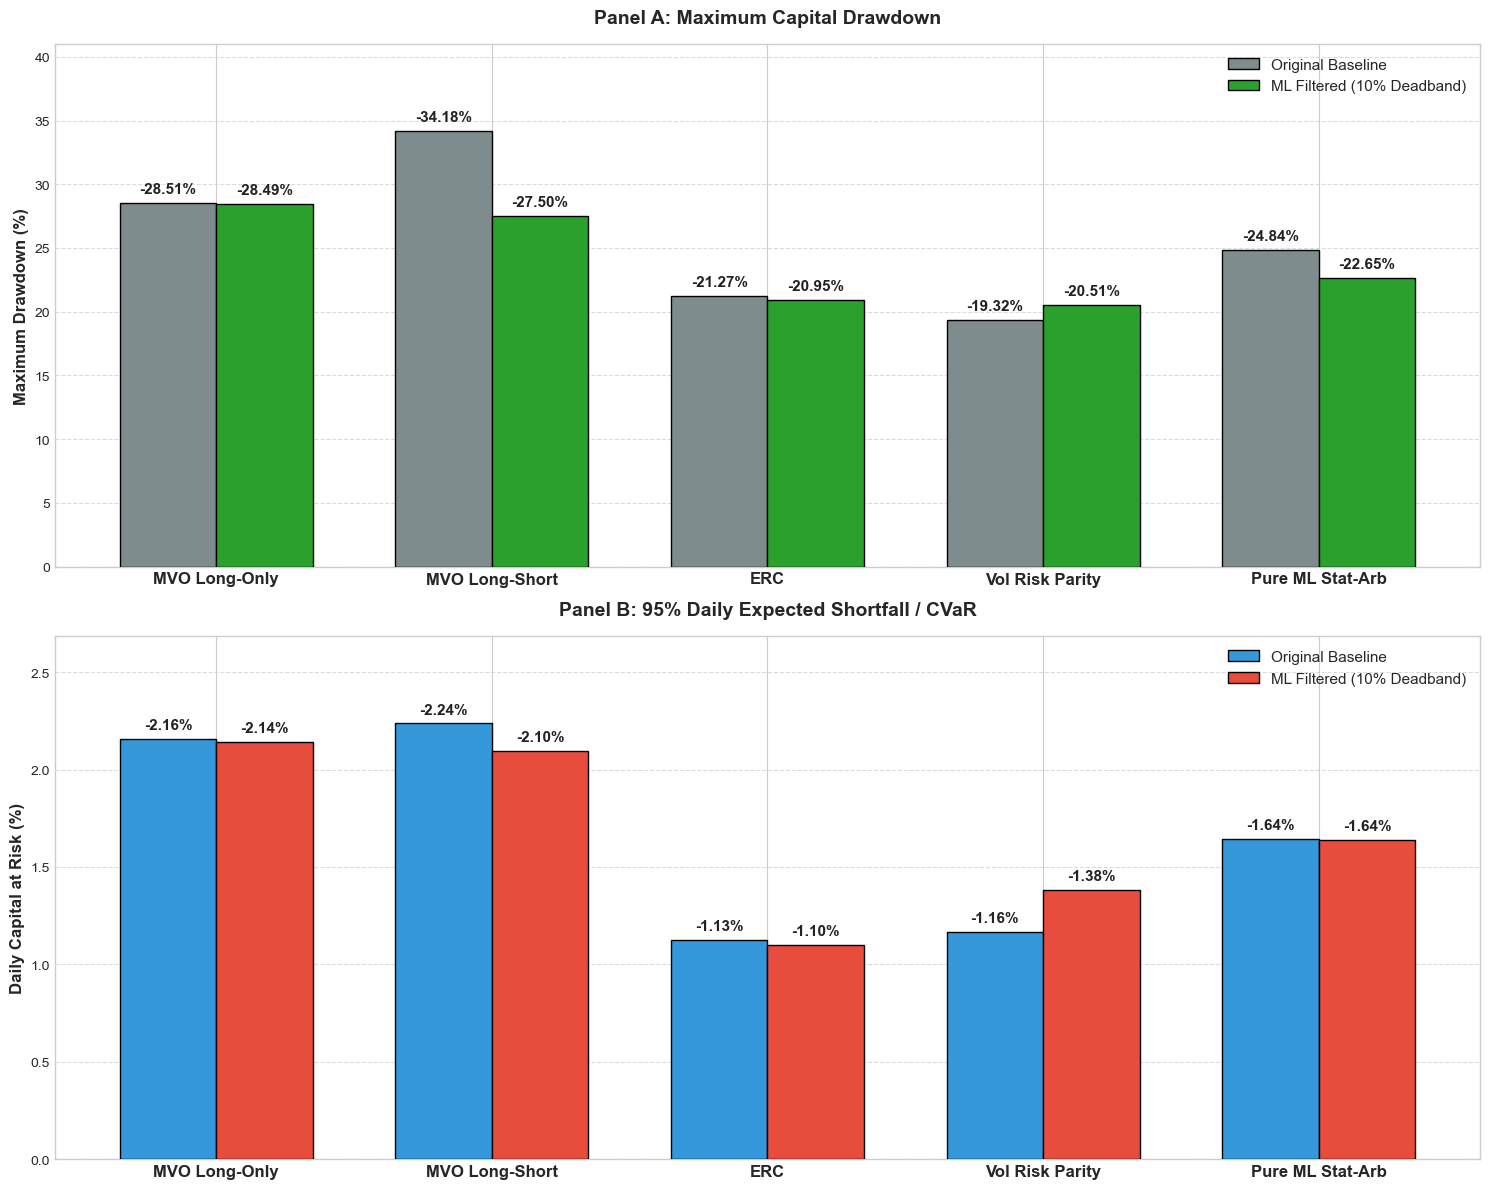

In [4]:
# ==============================================================================
# TAIL RISK ANALYSIS
# ==============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("[INFO] Computing Comprehensive Tail Risk Metrics Across All Architectures...")

# Assuming `aligned_daily_rets`, `base_weights`, and `ml_filtered_weights` are in memory
assets_list = [c for c in aligned_daily_rets.columns if c != 'VFISX']
alloc_keys = ['MVO_LO', 'MVO_LS', 'ERC', 'VRP', 'PURE_LO']
labels = ['MVO Long-Only', 'MVO Long-Short', 'ERC', 'Vol Risk Parity', 'Pure ML Stat-Arb']

# Storage for plotting
base_max_dds, filt_max_dds = [], []
base_cvars, filt_cvars = [], []

def get_daily_port_rets(weights_dict, key, is_pure_lo_base=False):
    # Forward fill monthly weights to daily
    w_daily = weights_dict[key].dropna().reindex(aligned_daily_rets.index).ffill().shift(1).dropna()
    if is_pure_lo_base:
        w_daily.loc[:, :] = 1.0 / len(assets_list)
        
    valid_rets = aligned_daily_rets[assets_list].loc[w_daily.index]
    return (w_daily * valid_rets).sum(axis=1)

def calc_max_dd(daily_rets):
    cum_rets = (1 + daily_rets).cumprod()
    peak = cum_rets.cummax()
    dd = (cum_rets - peak) / peak
    return abs(dd.min() * 100) # Return as positive % for bar charting

def calc_cvar(daily_rets, confidence=0.05):
    var_95 = np.percentile(daily_rets, confidence * 100)
    cvar_95 = daily_rets[daily_rets <= var_95].mean()
    return abs(cvar_95 * 100) # Return as positive % for bar charting

# Calculate metrics for all models
for key in alloc_keys:
    is_base = (key == 'PURE_LO')
    
    # Get daily return streams
    ret_base = get_daily_port_rets(base_weights, key, is_pure_lo_base=is_base)
    ret_filt = get_daily_port_rets(ml_filtered_weights, key)
    
    # Calculate Drawdowns
    base_max_dds.append(calc_max_dd(ret_base))
    filt_max_dds.append(calc_max_dd(ret_filt))
    
    # Calculate Expected Shortfall (CVaR)
    base_cvars.append(calc_cvar(ret_base))
    filt_cvars.append(calc_cvar(ret_filt))

# ==============================================================================
# VISUALIZATION: SYSTEMATIC TAIL RISK REDUCTION
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

x = np.arange(len(alloc_keys))
width = 0.35

def add_clean_labels(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'-{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#222222')

# --- Panel A: Maximum Drawdown ---
rects1 = ax1.bar(x - width/2, base_max_dds, width, label='Original Baseline', color='#7f8c8d', edgecolor='black', zorder=3)
rects2 = ax1.bar(x + width/2, filt_max_dds, width, label='ML Filtered (10% Deadband)', color='#2ca02c', edgecolor='black', zorder=3)

ax1.set_title('Panel A: Maximum Capital Drawdown', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Maximum Drawdown (%)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax1.margins(y=0.2)
ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax1.legend(loc='upper right', fontsize=11, edgecolor='black', framealpha=1)

add_clean_labels(rects1, ax1)
add_clean_labels(rects2, ax1)

# --- Panel B: 95% Expected Shortfall (CVaR) ---
rects3 = ax2.bar(x - width/2, base_cvars, width, label='Original Baseline', color='#3498db', edgecolor='black', zorder=3)
rects4 = ax2.bar(x + width/2, filt_cvars, width, label='ML Filtered (10% Deadband)', color='#e74c3c', edgecolor='black', zorder=3)

ax2.set_title('Panel B: 95% Daily Expected Shortfall / CVaR', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Daily Capital at Risk (%)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax2.margins(y=0.2)
ax2.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax2.legend(loc='upper right', fontsize=11, edgecolor='black', framealpha=1)

add_clean_labels(rects3, ax2)
add_clean_labels(rects4, ax2)

plt.tight_layout()
#plt.savefig('Systematic_Risk_Reduction_Summary.png', dpi=300, bbox_inches='tight')
plt.show()

#print("\n[SUCCESS] Exported 'Systematic_Risk_Reduction_Summary.png'")

[INFO] Generating Logarithmic 5-Panel Architecture Deconstruction Curves (Gross & Net)...


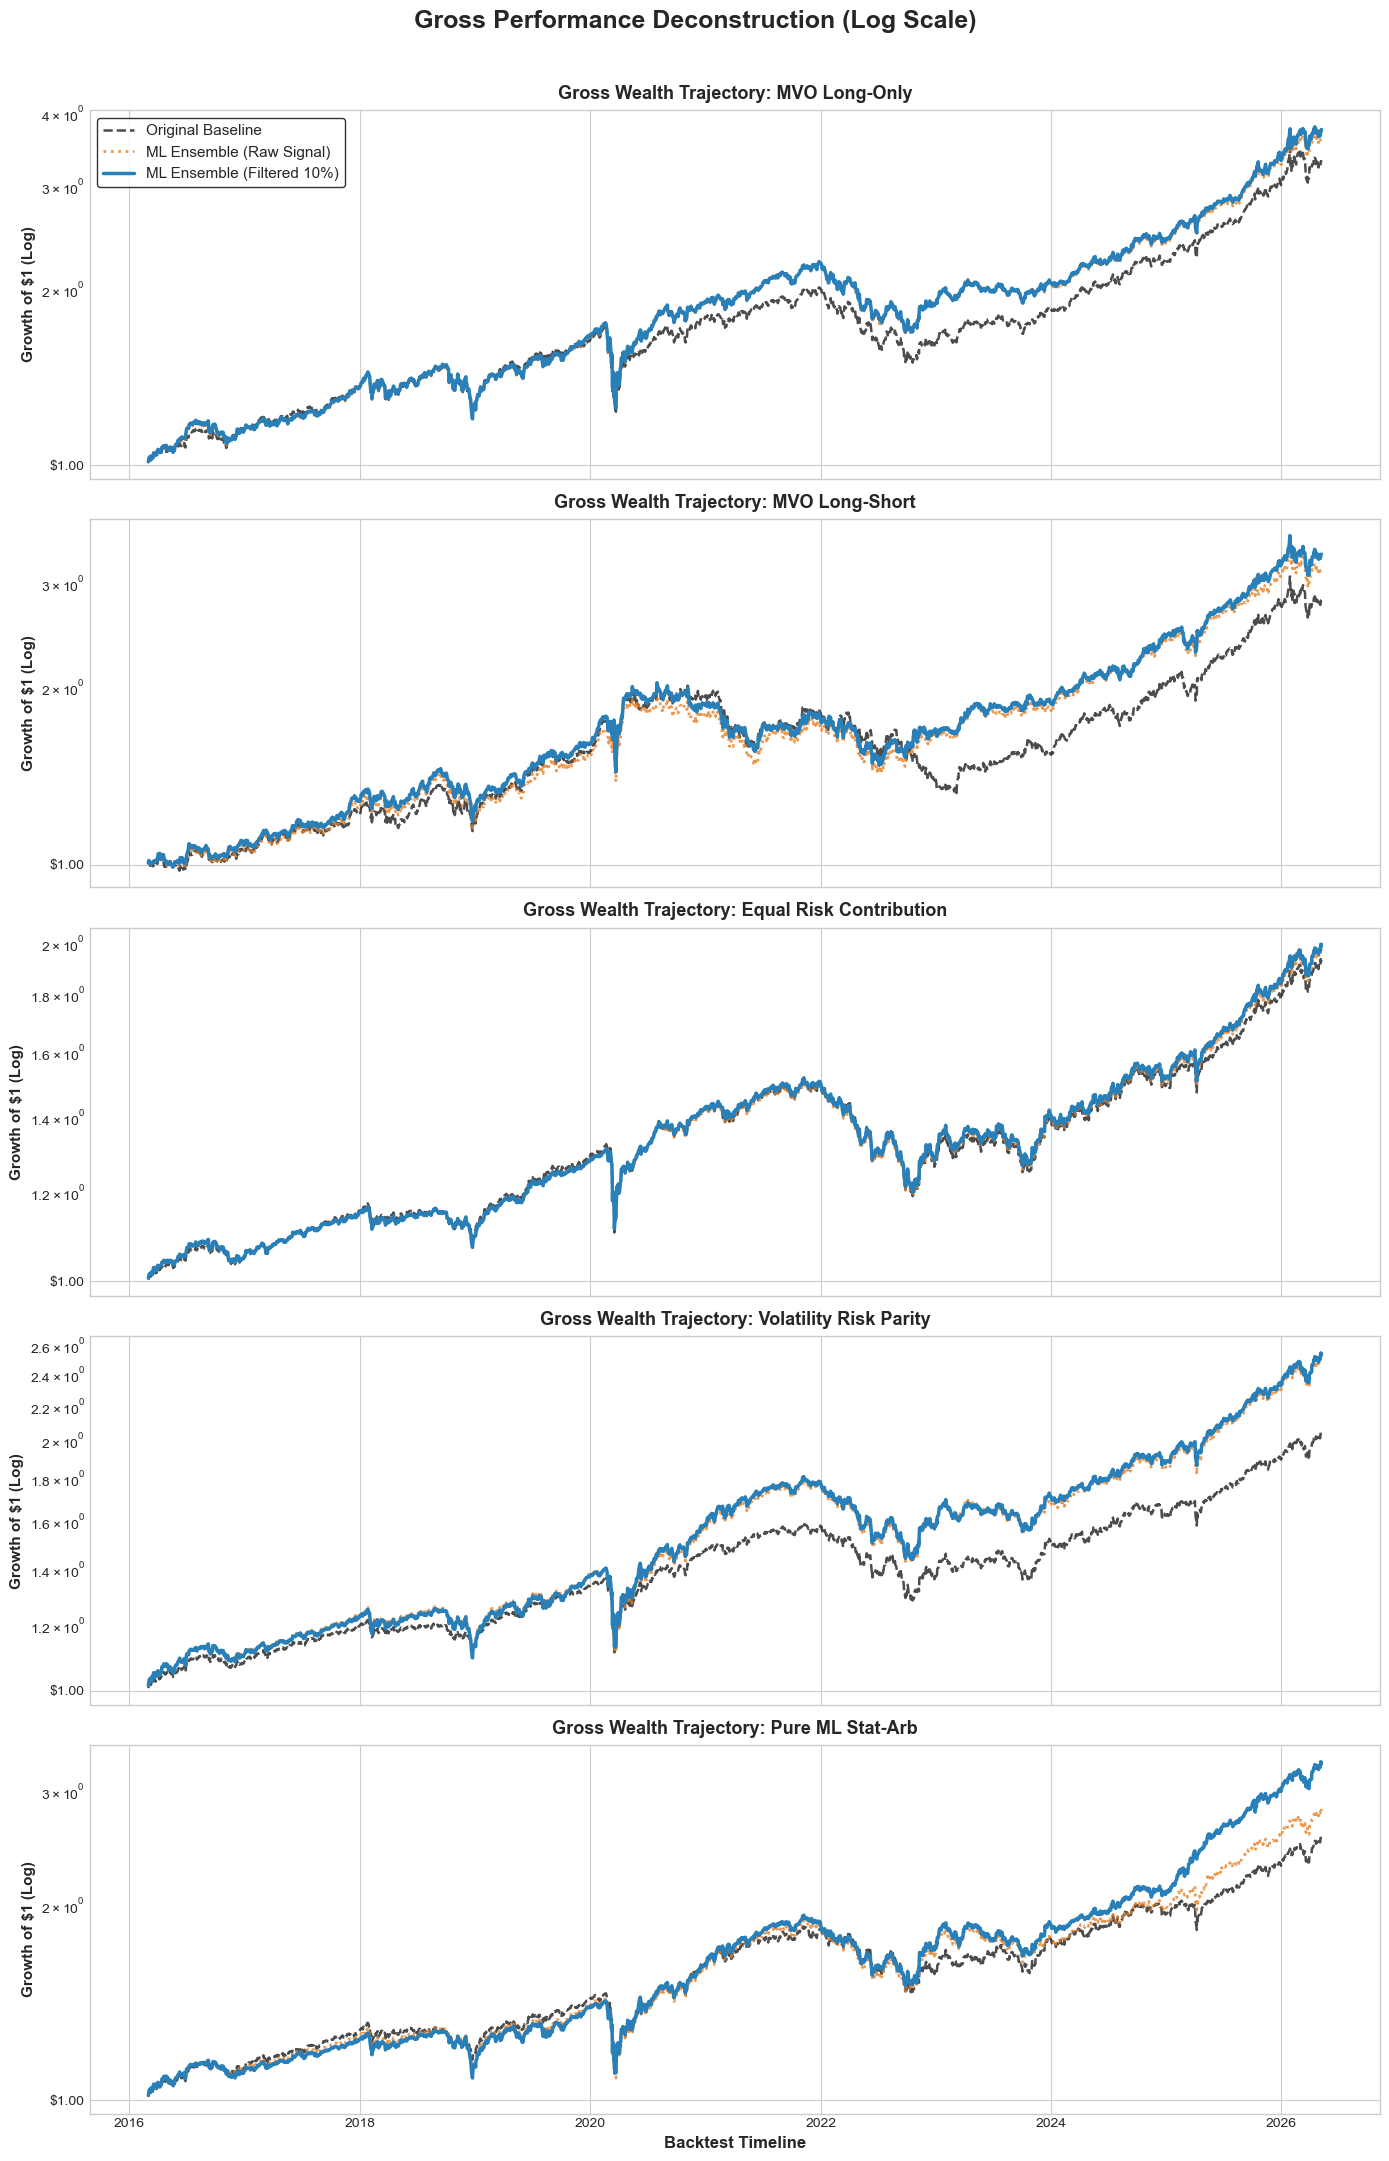

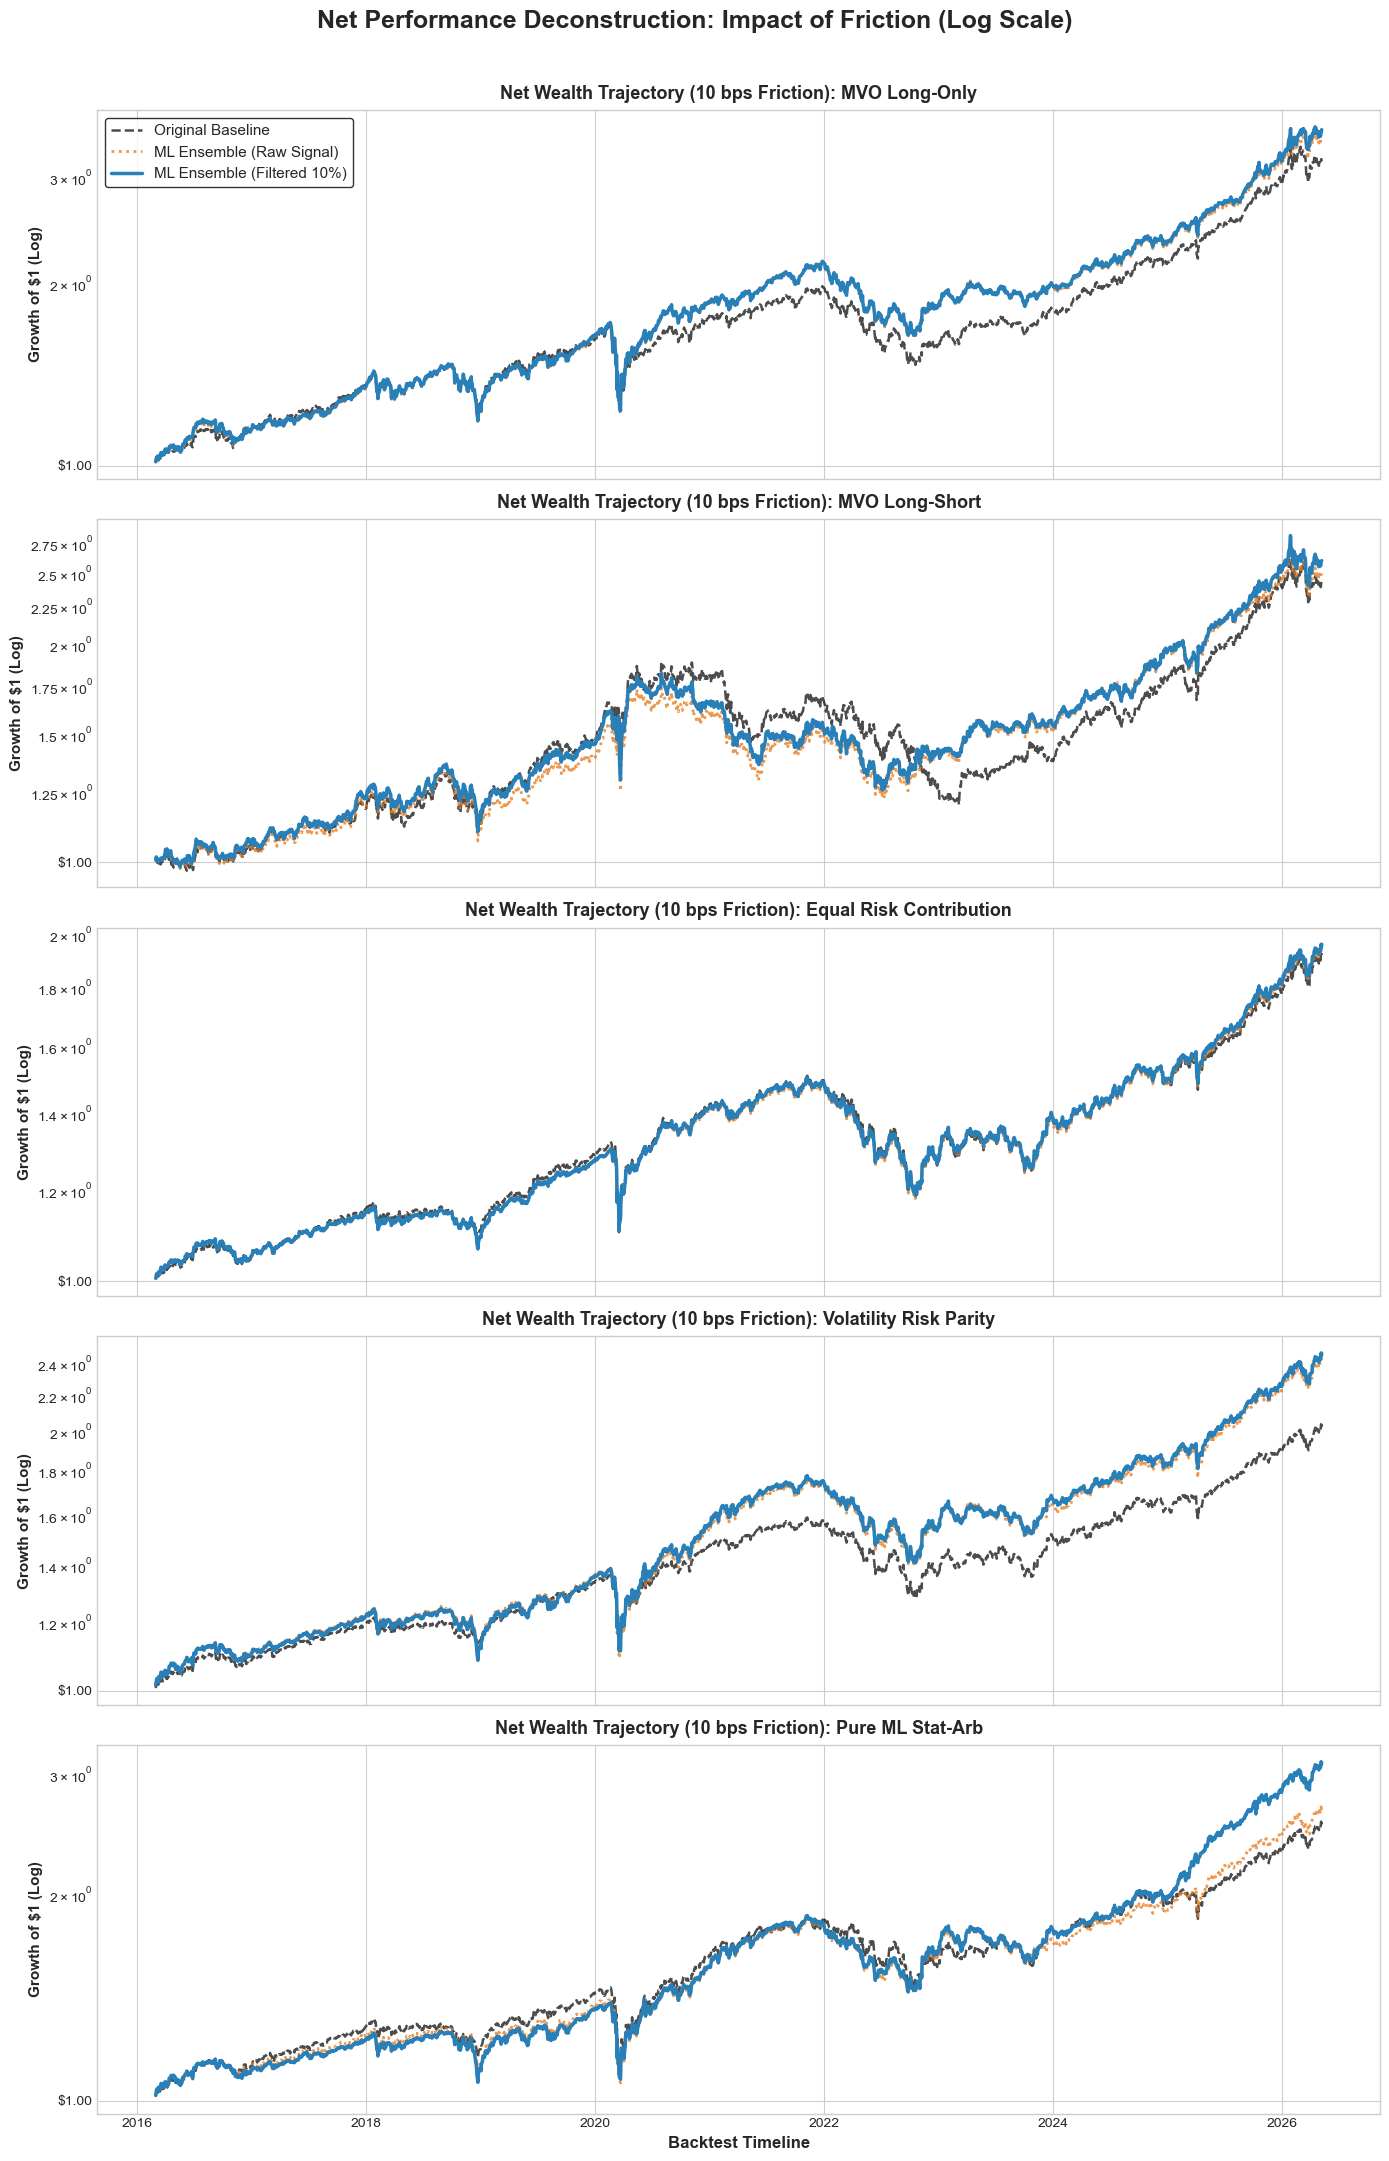

In [5]:
# ==============================================================================
# CUMULATIVE RETURN PLOTS OVER TIME
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

print("[INFO] Generating Logarithmic 5-Panel Architecture Deconstruction Curves (Gross & Net)...")

alloc_keys = ['MVO_LO', 'MVO_LS', 'ERC', 'VRP', 'PURE_LO']
labels = ['MVO Long-Only', 'MVO Long-Short', 'Equal Risk Contribution', 'Volatility Risk Parity', 'Pure ML Stat-Arb']

plt.style.use('seaborn-v0_8-whitegrid')

# Initialize the two massive figures
fig_gross, axes_gross = plt.subplots(5, 1, figsize=(14, 22), sharex=True)
fig_net, axes_net = plt.subplots(5, 1, figsize=(14, 22), sharex=True)

# Helper function to calculate exact daily Gross and Net wealth curves
def get_wealth_curves(weight_df, is_pure_lo_base=False):
    if is_pure_lo_base:
        w = weight_df.copy()
        w.loc[:, :] = 1.0 / len(assets_list)
    else:
        w = weight_df

    # Gross Returns
    w_daily = w.dropna().reindex(aligned_daily_rets.index).ffill().shift(1).dropna()
    valid_excess = aligned_daily_excess_all[w_daily.columns].loc[w_daily.index]
    gross_excess_ret = (w_daily * valid_excess).sum(axis=1)
    gross_total_ret = gross_excess_ret + aligned_daily_rf.loc[gross_excess_ret.index]
    
    # Net Returns (Turnover Drag)
    w_start = w.dropna().shift(1).dropna()
    valid_monthly_raw = monthly_returns[w_start.columns].loc[w_start.index]
    w_drift = w_start * (1 + valid_monthly_raw)
    
    w_drift_norm = w_drift.div(w_drift.sum(axis=1).replace(0, 1), axis=0) 
    w_target = w.loc[w_drift_norm.index]
    w_target_norm = w_target.div(w_target.sum(axis=1).replace(0, 1), axis=0)
        
    turnover_monthly = (w_target_norm - w_drift_norm).abs().sum(axis=1) / 2.0
    ann_turnover = turnover_monthly.mean() * 12
    daily_tc_drag = (ann_turnover * 2.0 * 0.0010) / 252.0 if not is_pure_lo_base else 0.0
    
    net_total_ret = gross_total_ret - daily_tc_drag
    
    return (1 + gross_total_ret).cumprod(), (1 + net_total_ret).cumprod()

# ==============================================================================
# LOOP THROUGH EACH ARCHITECTURE & PLOT
# ==============================================================================
for idx, key in enumerate(alloc_keys):
    ax_g = axes_gross[idx]
    ax_n = axes_net[idx]
    
    is_pure_base = (key == 'PURE_LO')
    gross_base, net_base = get_wealth_curves(base_weights[key], is_pure_lo_base=is_pure_base)
    gross_raw, net_raw = get_wealth_curves(ml_raw_weights[key])
    gross_filt, net_filt = get_wealth_curves(ml_filtered_weights[key])
    
    base_label = "Passive 1/N Baseline" if is_pure_base else "Original Baseline"
    
    # 1. Plot Gross Panel (LOG SCALE)
    ax_g.plot(gross_base.index, gross_base, label=base_label, color='black', linestyle='--', linewidth=1.8, alpha=0.7)
    ax_g.plot(gross_raw.index, gross_raw, label='ML Ensemble (Raw Signal)', color='#e67e22', linestyle=':', linewidth=2, alpha=0.8)
    ax_g.plot(gross_filt.index, gross_filt, label='ML Ensemble (Filtered 10%)', color='#2980b9', linewidth=2.5)
    
    ax_g.set_title(f'Gross Wealth Trajectory: {labels[idx]}', fontsize=13, fontweight='bold', pad=8)
    ax_g.set_ylabel('Growth of $1 (Log)', fontsize=11, fontweight='bold')
    ax_g.set_yscale('log')
    ax_g.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.2f}"))
    if idx == 0: ax_g.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=11)

    # 2. Plot Net Panel (LOG SCALE)
    ax_n.plot(net_base.index, net_base, label=base_label, color='black', linestyle='--', linewidth=1.8, alpha=0.7)
    ax_n.plot(net_raw.index, net_raw, label='ML Ensemble (Raw Signal)', color='#e67e22', linestyle=':', linewidth=2, alpha=0.8)
    ax_n.plot(net_filt.index, net_filt, label='ML Ensemble (Filtered 10%)', color='#2980b9', linewidth=2.5)
    
    ax_n.set_title(f'Net Wealth Trajectory (10 bps Friction): {labels[idx]}', fontsize=13, fontweight='bold', pad=8)
    ax_n.set_ylabel('Growth of $1 (Log)', fontsize=11, fontweight='bold')
    ax_n.set_yscale('log')
    ax_n.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.2f}"))
    if idx == 0: ax_n.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=11)

# Format and Save Gross Figure
axes_gross[-1].set_xlabel('Backtest Timeline', fontsize=12, fontweight='bold')
fig_gross.suptitle('Gross Performance Deconstruction (Log Scale)', fontsize=18, fontweight='bold', y=0.98)
fig_gross.tight_layout(rect=[0, 0, 1, 0.97])
#fig_gross.savefig('Portfolio_5Panel_Gross_Log.png', dpi=300, bbox_inches='tight')

# Format and Save Net Figure
axes_net[-1].set_xlabel('Backtest Timeline', fontsize=12, fontweight='bold')
fig_net.suptitle('Net Performance Deconstruction: Impact of Friction (Log Scale)', fontsize=18, fontweight='bold', y=0.98)
fig_net.tight_layout(rect=[0, 0, 1, 0.97])
#fig_net.savefig('Portfolio_5Panel_Net_Log.png', dpi=300, bbox_inches='tight')

plt.show()
#print("[SUCCESS] Exported 'Portfolio_5Panel_Gross_Log.png' and 'Portfolio_5Panel_Net_Log.png'")

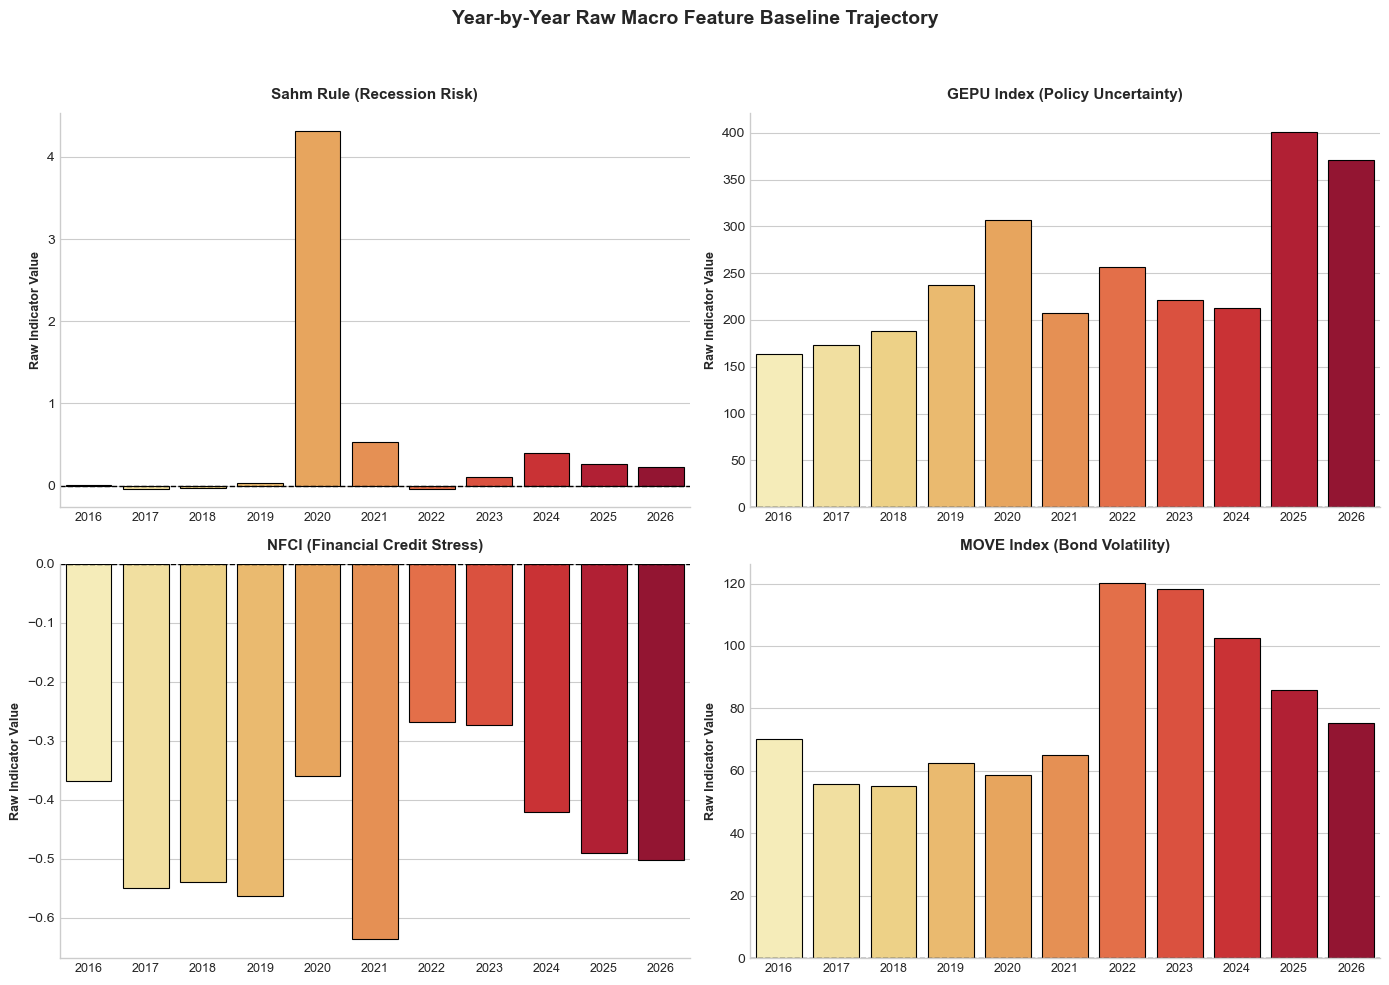

In [6]:
# ==============================================================================
# MACRO FEATURES ANNUAL PERFORMANCE
# ==============================================================================


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Select the core 4 alternative macro indicators directly from your dataset
macro_cols = ['SAHMREALTIME', 'GEPUCURRENT', 'NFCI', '^MOVE']
labels = [
    'Sahm Rule (Recession Risk)', 
    'GEPU Index (Policy Uncertainty)', 
    'NFCI (Financial Credit Stress)', 
    'MOVE Index (Bond Volatility)'
]

# 2. Extract the raw series and slice the out-of-sample presentation timeline
sample_df = features_dict[assets_list[0]][macro_cols].loc['2016-01-01':'2026-05-01']

# 3. Setup a clean 2x2 grid for the subgraphs
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 4. Loop through each indicator and compute straight annual arithmetic means
for i, col in enumerate(macro_cols):
    # Group by the timestamp year and compute the raw mean
    annual_means = sample_df[col].groupby(sample_df.index.year).mean()
    
    # Plot on its respective subgraph panel
    sns.barplot(
        x=annual_means.index, 
        y=annual_means.values, 
        ax=axes[i], 
        palette='YlOrRd', 
        edgecolor='black', 
        linewidth=0.8
    )
    
    # Format individual panel markers
    axes[i].set_title(labels[i], fontsize=11, fontweight='bold', pad=10)
    axes[i].set_ylabel('Raw Indicator Value', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[i].tick_params(axis='x', labelsize=9)

# Clean up layout structure
sns.despine()
plt.suptitle('Year-by-Year Raw Macro Feature Baseline Trajectory', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Export clean graphic for your presentation slides
#plt.savefig('Alternative_Macro_Annual_Raw_Means.png', dpi=300)
plt.show()

#print("[SUCCESS] Exported 'Alternative_Macro_Annual_Raw_Means.png' containing all 4 subgraphs.")